<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/breast-cancer-eda-ml-dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings("ignore")


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 128

In [9]:
df=pd.read_csv('breast_cancer.csv')
print("Dataset loaded sucessfully!")
print(f"shape:{df.shape}")

Dataset loaded sucessfully!
shape:(569, 33)


In [10]:
print("=" * 60)
print("First 5 rows")
print("=" * 60)
df.head()

First 5 rows


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
print("=" * 60)
print("Last 5 rows")
print("=" * 60)
df.tail()

Last 5 rows


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [12]:
print("=" * 60)
print("Stastical Summery")
print("=" * 60)
df.describe().T

Stastical Summery


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [13]:
print("=" * 60)
print("Dataframe Info")
print("=" * 60)
df.info()

Dataframe Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

In [16]:
print("=" * 60)
print("Missing Values")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing value found")



Missing Values
Unnamed: 32    569
dtype: int64


In [17]:
print("=" * 60)
print("Categorical Columns")
print("=" * 60)
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

Categorical Columns
Categorical columns: ['diagnosis']


In [21]:
print("=" * 60)
print("Unique values per column)")
print("=" * 60)
for col in df.columns[:10]:
  print(f"{col:30s} → {df[col].nunique()} unique values")

Unique values per column)
id                             → 569 unique values
diagnosis                      → 2 unique values
radius_mean                    → 456 unique values
texture_mean                   → 479 unique values
perimeter_mean                 → 522 unique values
area_mean                      → 539 unique values
smoothness_mean                → 474 unique values
compactness_mean               → 537 unique values
concavity_mean                 → 537 unique values
concave points_mean            → 542 unique values


In [22]:
print("=" * 60)
print("Value Counts - Diagnosis")
print("=" * 60)
print(df['diagnosis'].value_counts())
print()
print(df['diagnosis'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Value Counts - Diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.74%
M    37.26%
Name: proportion, dtype: object


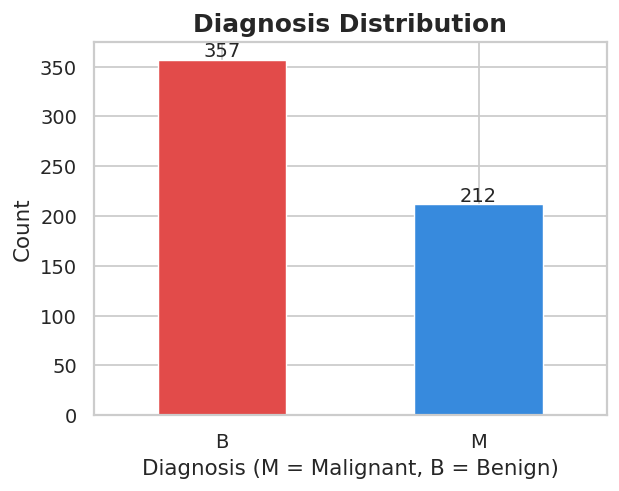

In [26]:
fig, ax = plt.subplots(figsize=(5,4))
colors = ["#E24B4A", "#378ADD"]
df["diagnosis"].value_counts().plot(kind="bar",color=colors,edgecolor="white",linewidth=0.8,ax=ax)
ax.set_title("Diagnosis Distribution",fontsize=14,fontweight="bold")
ax.set_xlabel("Diagnosis (M = Malignant, B = Benign)")
ax.set_ylabel("Count")
ax.tick_params(axis="x",rotation=0)
for p in ax.patches:
  ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height() + 3),ha="center",fontsize=11)
plt.tight_layout()
plt.show()

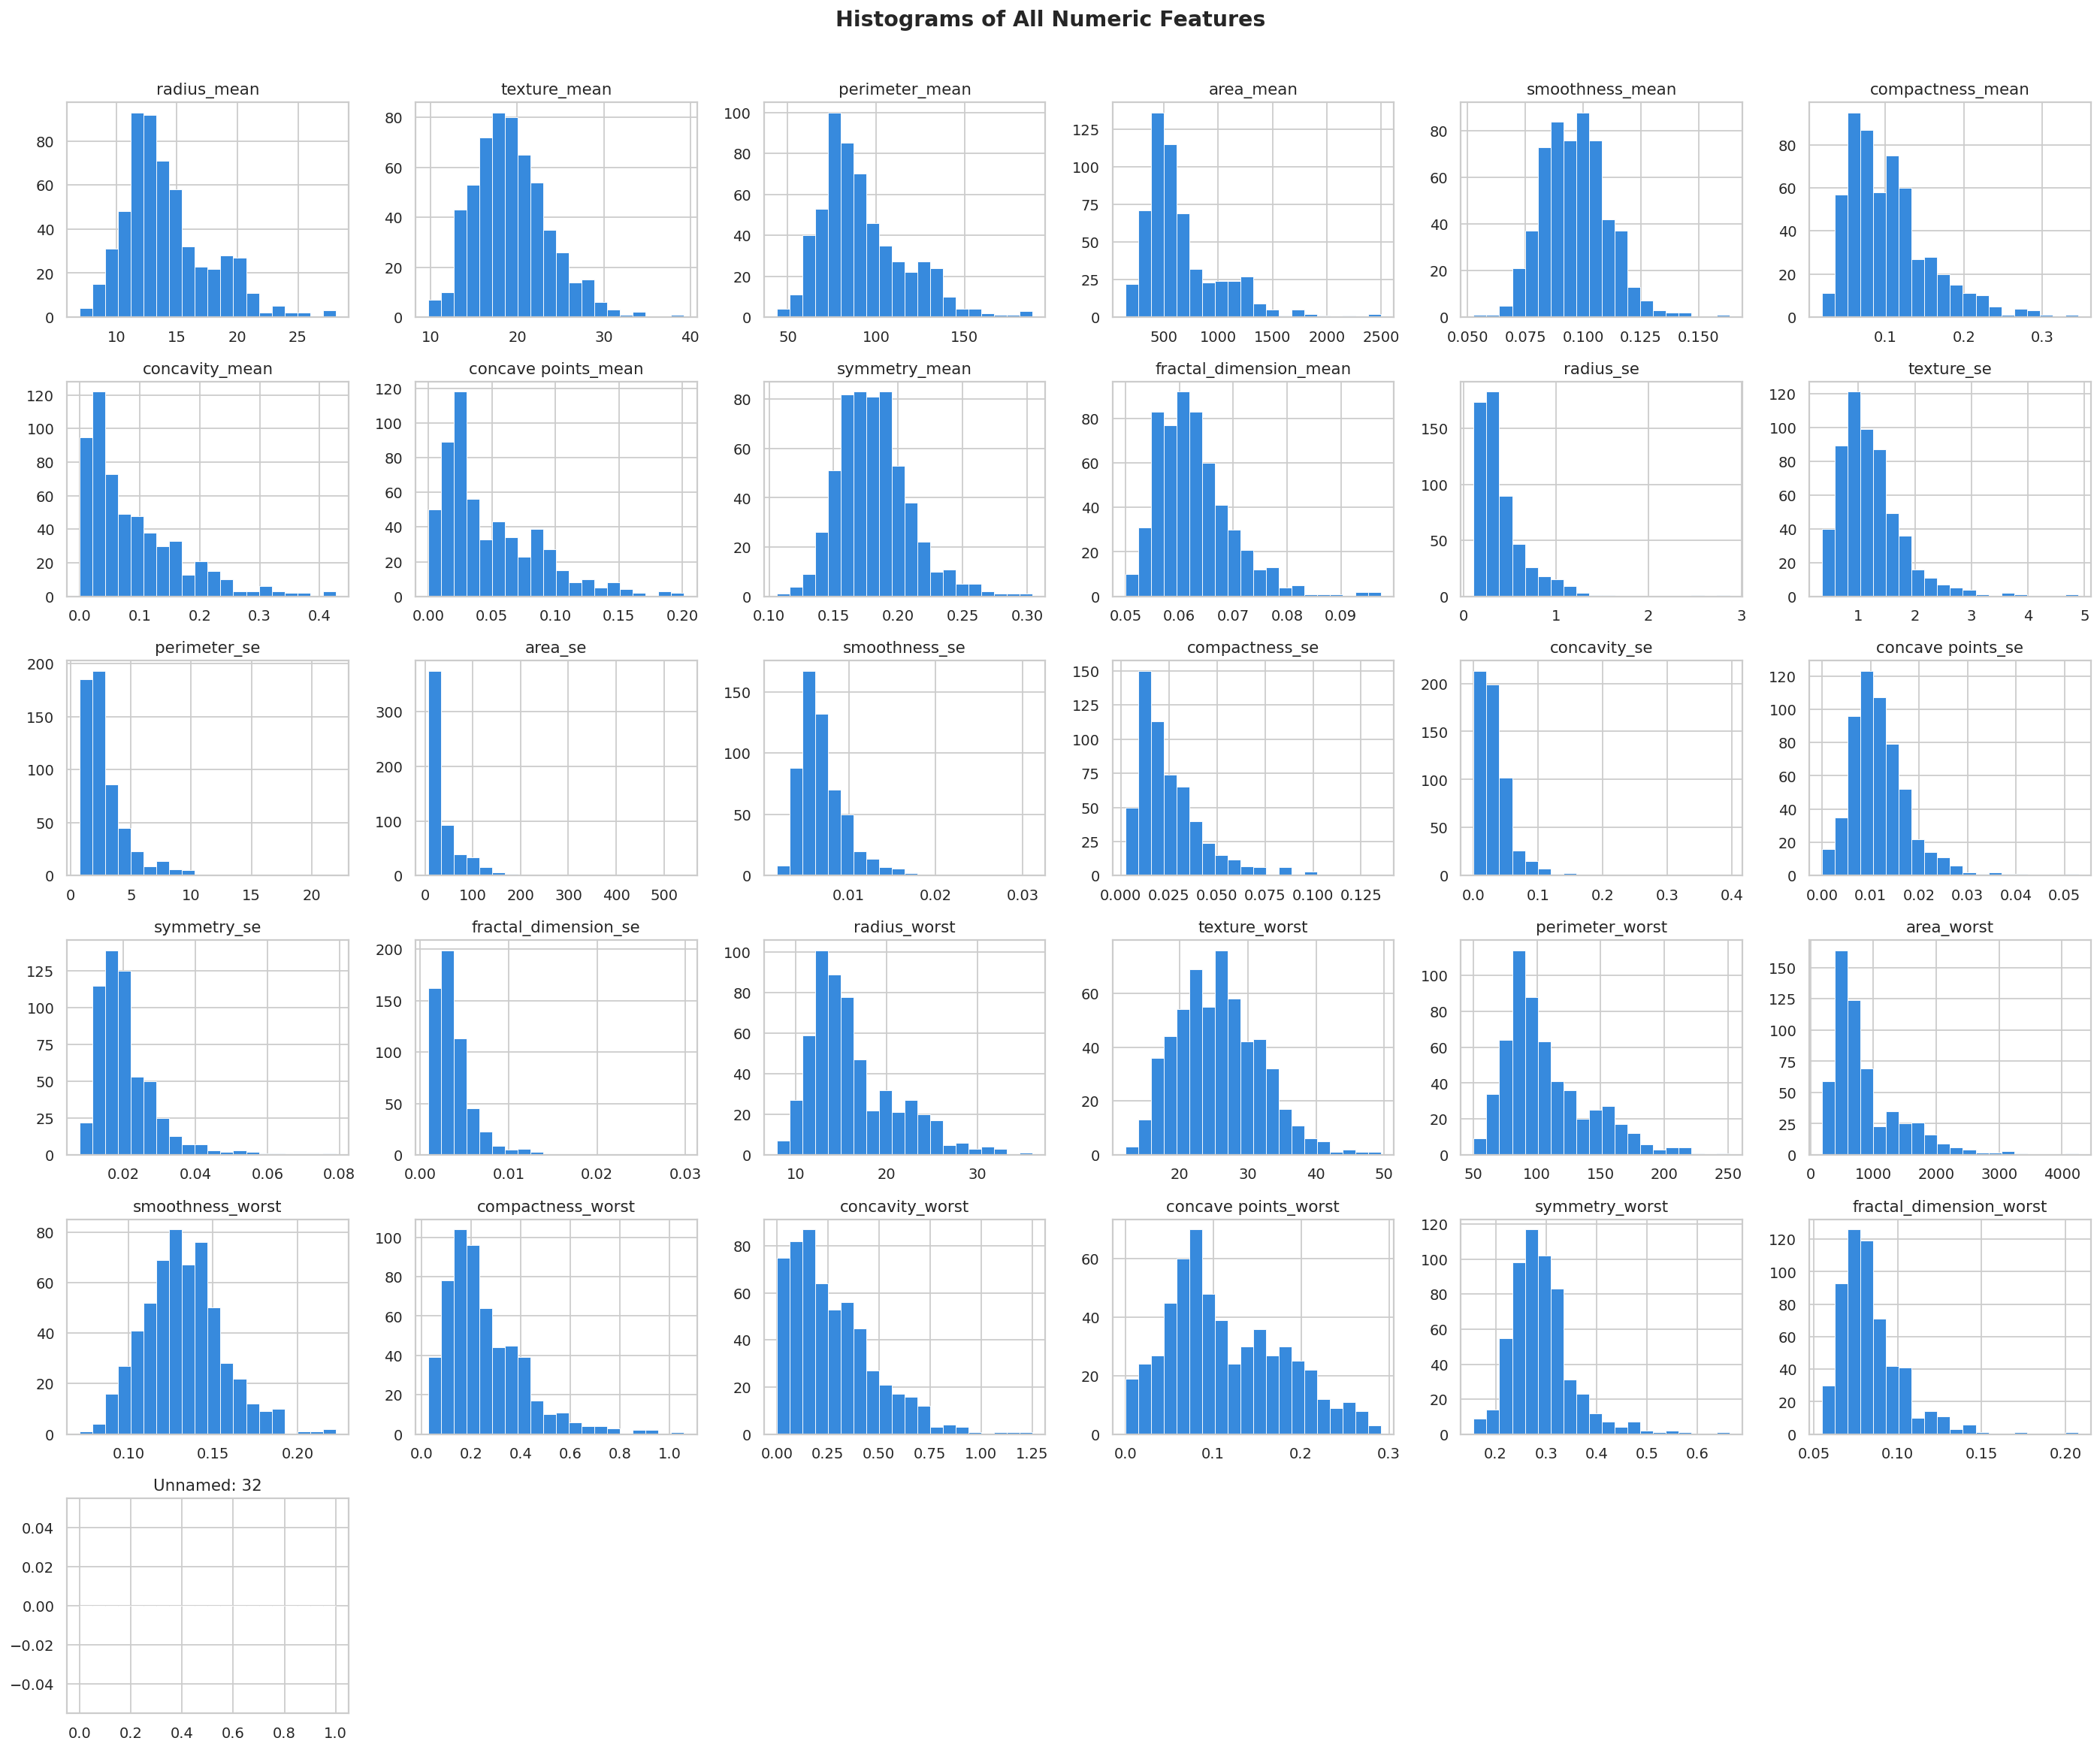

In [29]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("id")
df[numeric_cols].hist(bins=20, figsize=(22, 18), color="#378ADD",edgecolor="white", linewidth=0.5)
plt.suptitle("Histograms of All Numeric Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

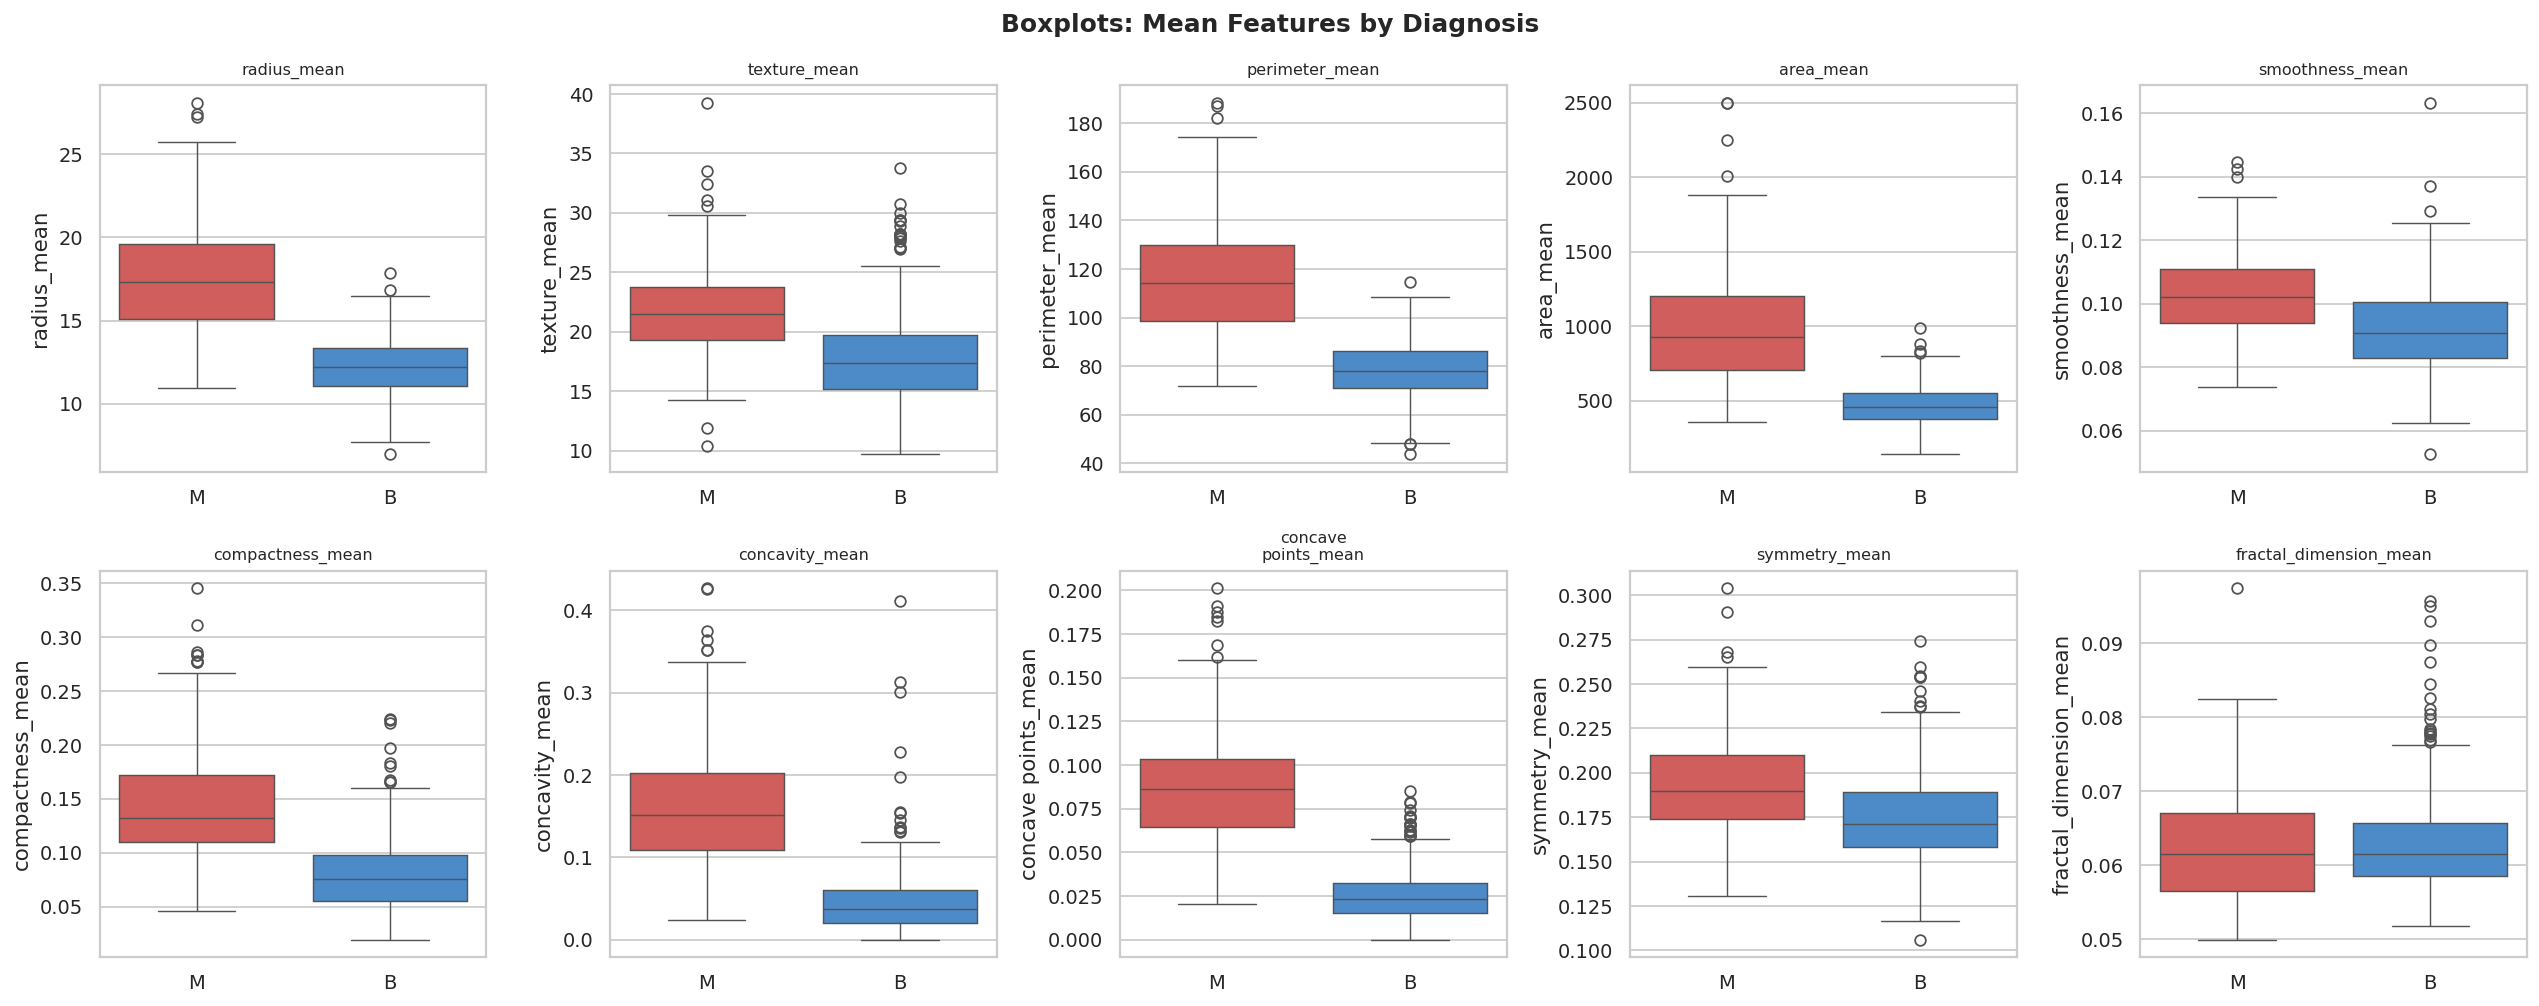

In [30]:
mean_cols = [c for c in numeric_cols if c.endswith("mean")]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(mean_cols):
    sns.boxplot(data=df, x="diagnosis", y=col, palette={"M": "#E24B4A", "B": "#378ADD"},
                ax=axes[i], linewidth=0.8)
    axes[i].set_title(col.replace(" ", "\n"), fontsize=9)
    axes[i].set_xlabel("")
plt.suptitle("Boxplots: Mean Features by Diagnosis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

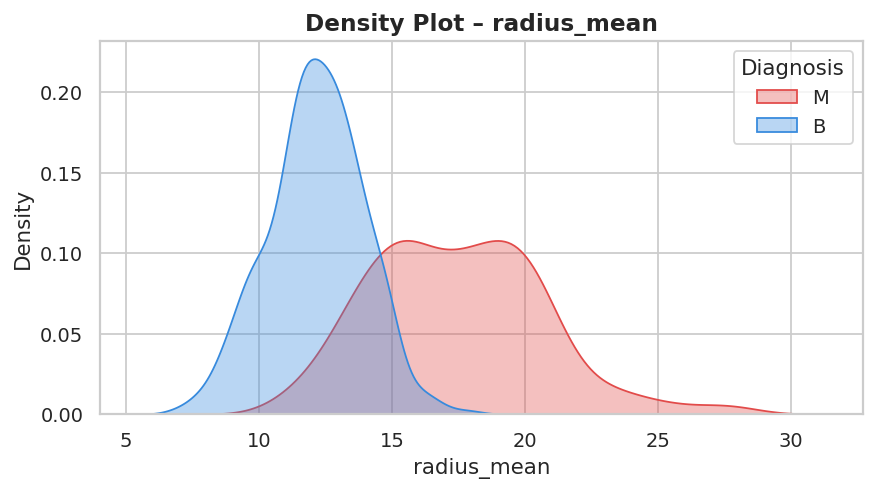

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [("M", "#E24B4A"), ("B", "#378ADD")]:
    sns.kdeplot(df.loc[df["diagnosis"] == label, "radius_mean"],
                label=label, color=color, fill=True, alpha=0.35, ax=ax)
ax.set_title("Density Plot – radius_mean", fontsize=13, fontweight="bold")
ax.set_xlabel("radius_mean")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

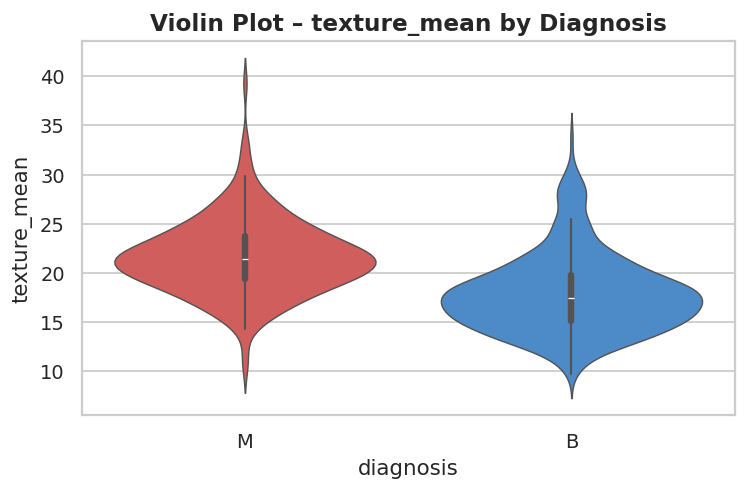

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=df, x="diagnosis", y="texture_mean",
               palette={"M": "#E24B4A", "B": "#378ADD"}, inner="box",
               linewidth=0.8, ax=ax)
ax.set_title("Violin Plot – texture_mean by Diagnosis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

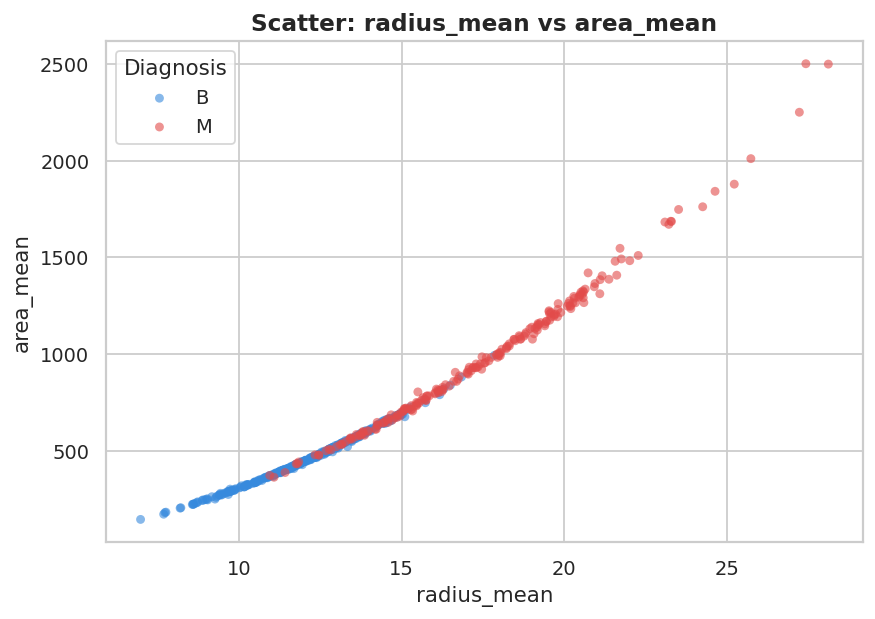

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
colors_map = {"M": "#E24B4A", "B": "#378ADD"}
for label, grp in df.groupby("diagnosis"):
    ax.scatter(grp["radius_mean"], grp["area_mean"],
               c=colors_map[label], label=label, alpha=0.6, s=25, edgecolors="none")
ax.set_xlabel("radius_mean")
ax.set_ylabel("area_mean")
ax.set_title("Scatter: radius_mean vs area_mean", fontsize=13, fontweight="bold")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

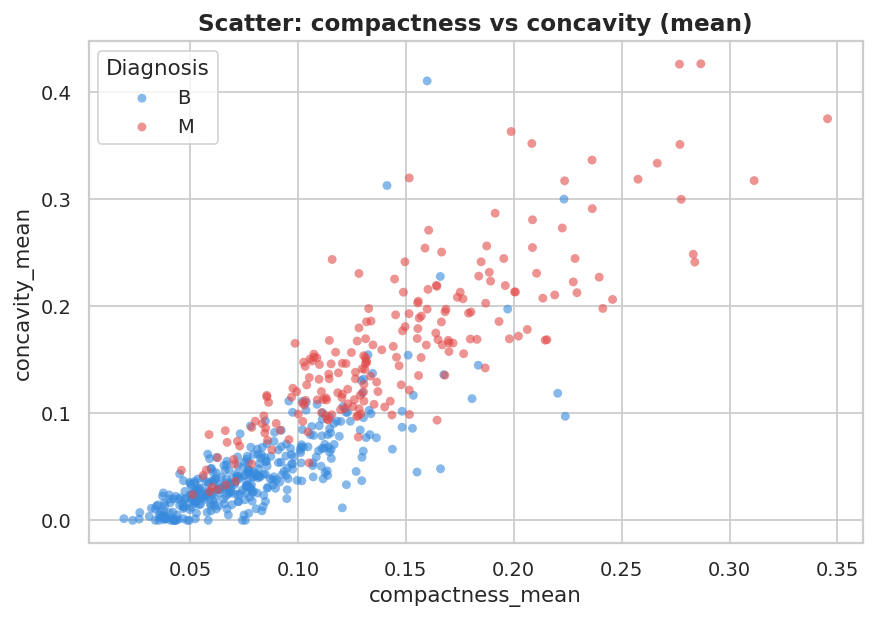

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, grp in df.groupby("diagnosis"):
    ax.scatter(grp["compactness_mean"], grp["concavity_mean"],
               c=colors_map[label], label=label, alpha=0.6, s=25, edgecolors="none")
ax.set_xlabel("compactness_mean")
ax.set_ylabel("concavity_mean")
ax.set_title("Scatter: compactness vs concavity (mean)", fontsize=13, fontweight="bold")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

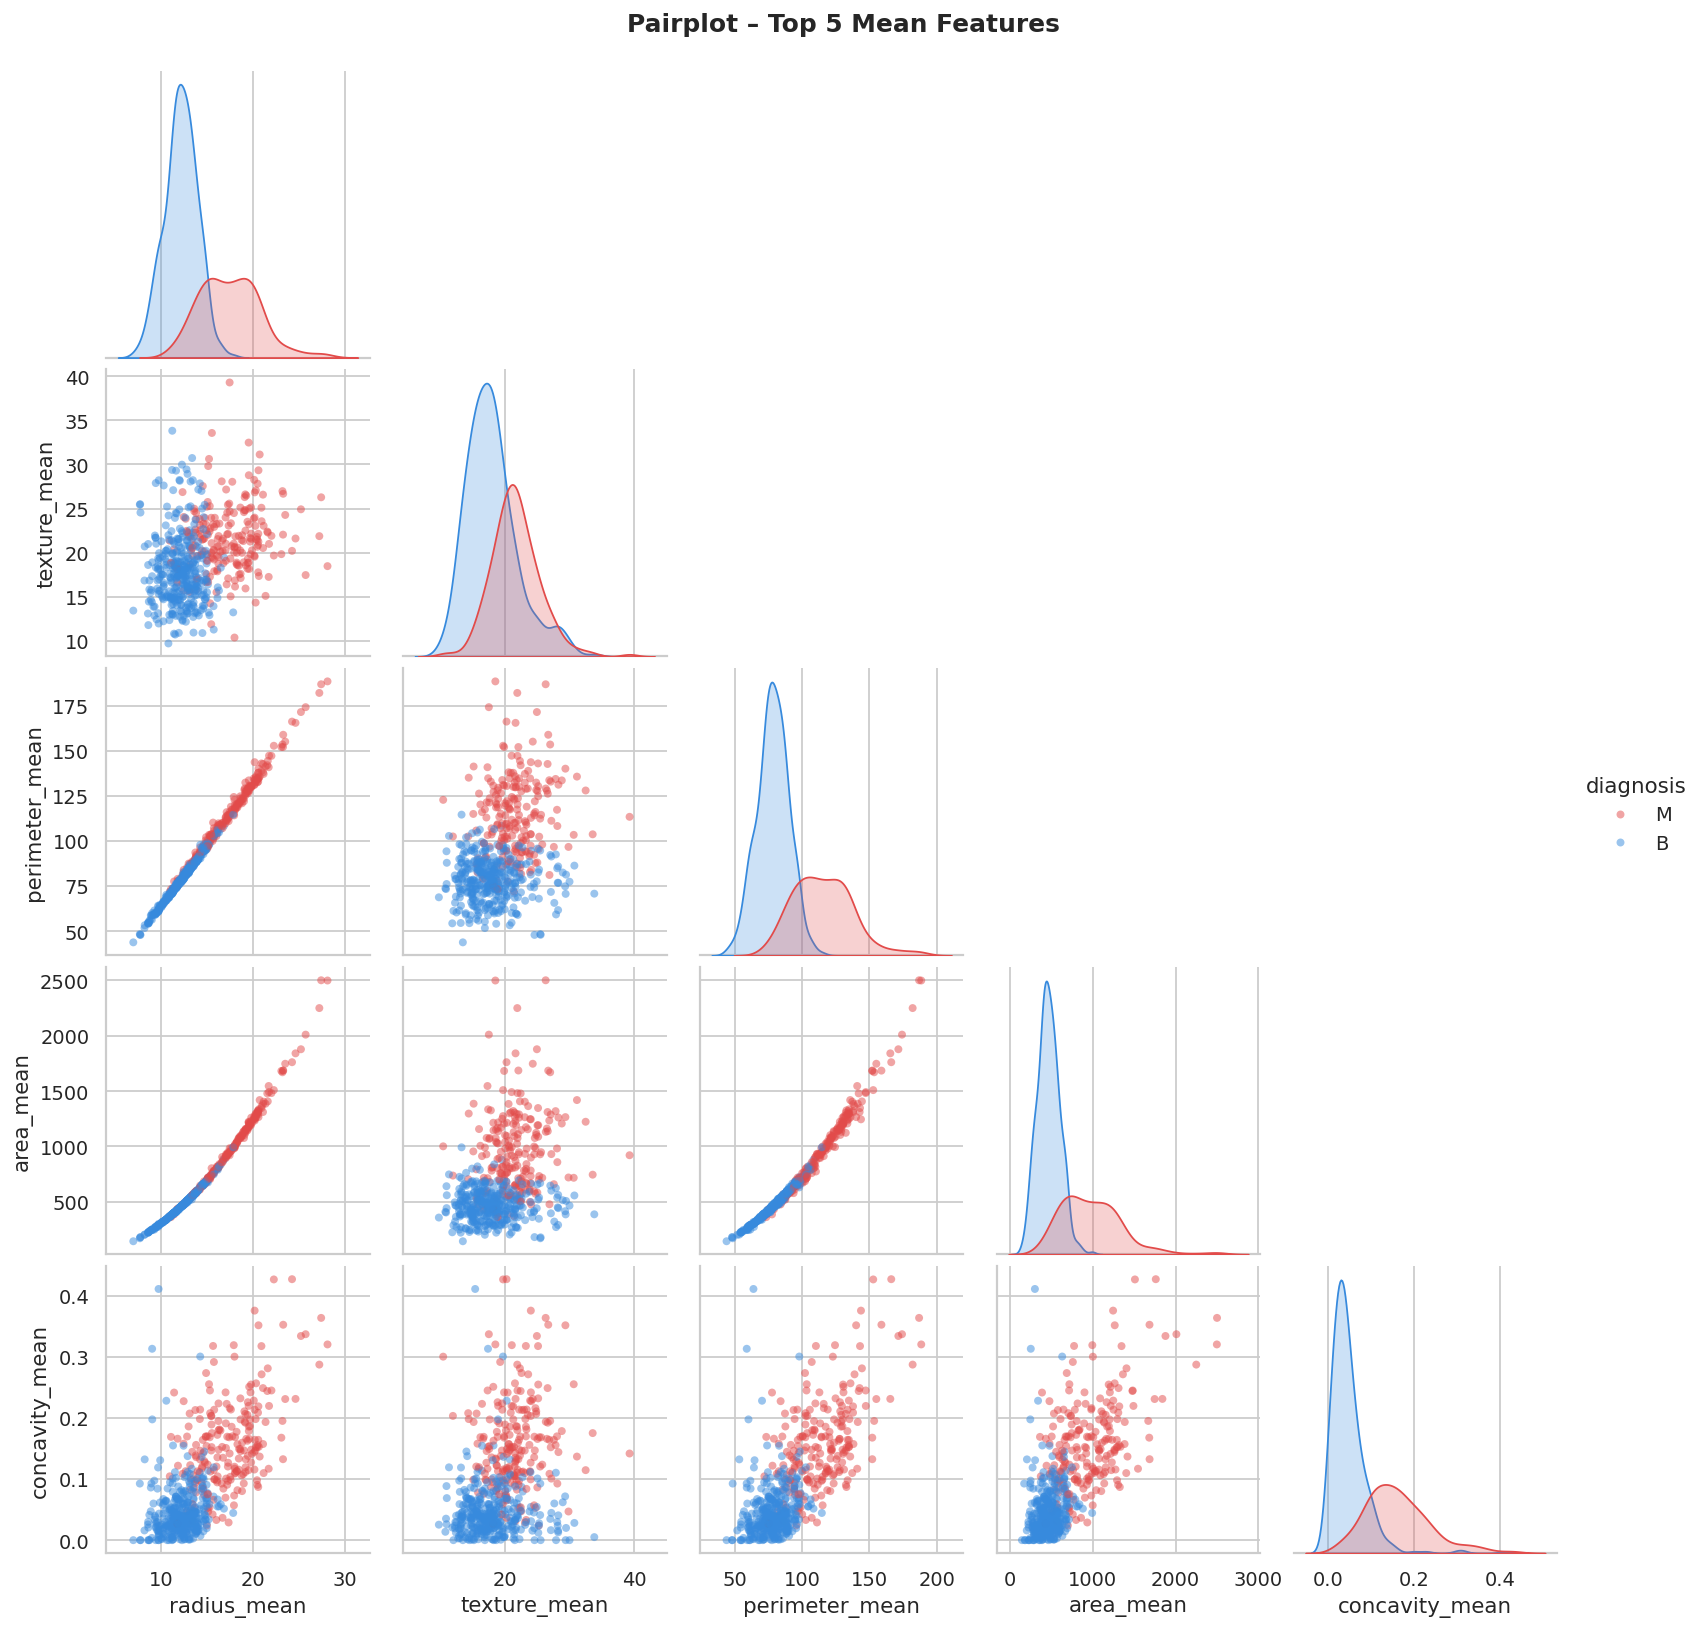

In [35]:
top5 = ["radius_mean", "texture_mean", "perimeter_mean",
        "area_mean", "concavity_mean", "diagnosis"]

pp = sns.pairplot(df[top5], hue="diagnosis",
                  palette={"M": "#E24B4A", "B": "#378ADD"},
                  plot_kws={"alpha": 0.5, "s": 20, "edgecolor": "none"},
                  diag_kind="kde", corner=True)
pp.fig.suptitle("Pairplot – Top 5 Mean Features", y=1.02,
                fontsize=14, fontweight="bold")
plt.show()

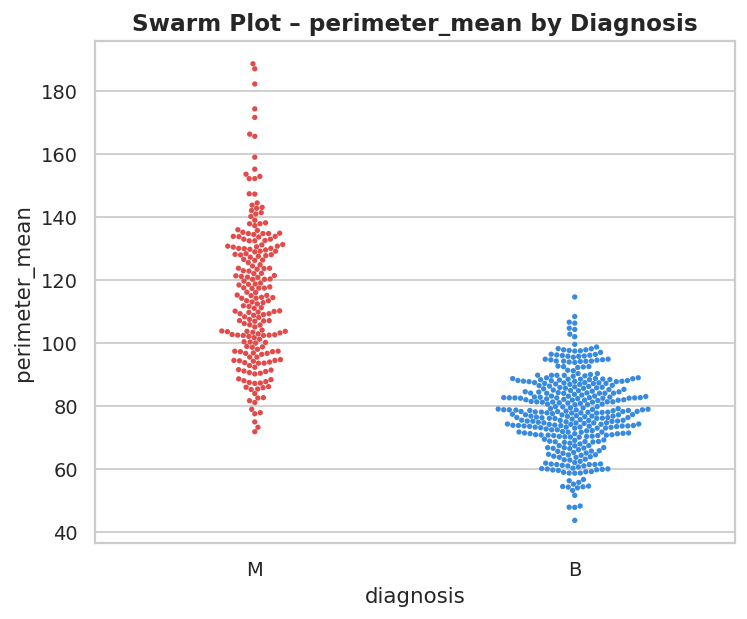

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.swarmplot(data=df, x="diagnosis", y="perimeter_mean",
              palette={"M": "#E24B4A", "B": "#378ADD"}, size=3, ax=ax)
ax.set_title("Swarm Plot – perimeter_mean by Diagnosis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

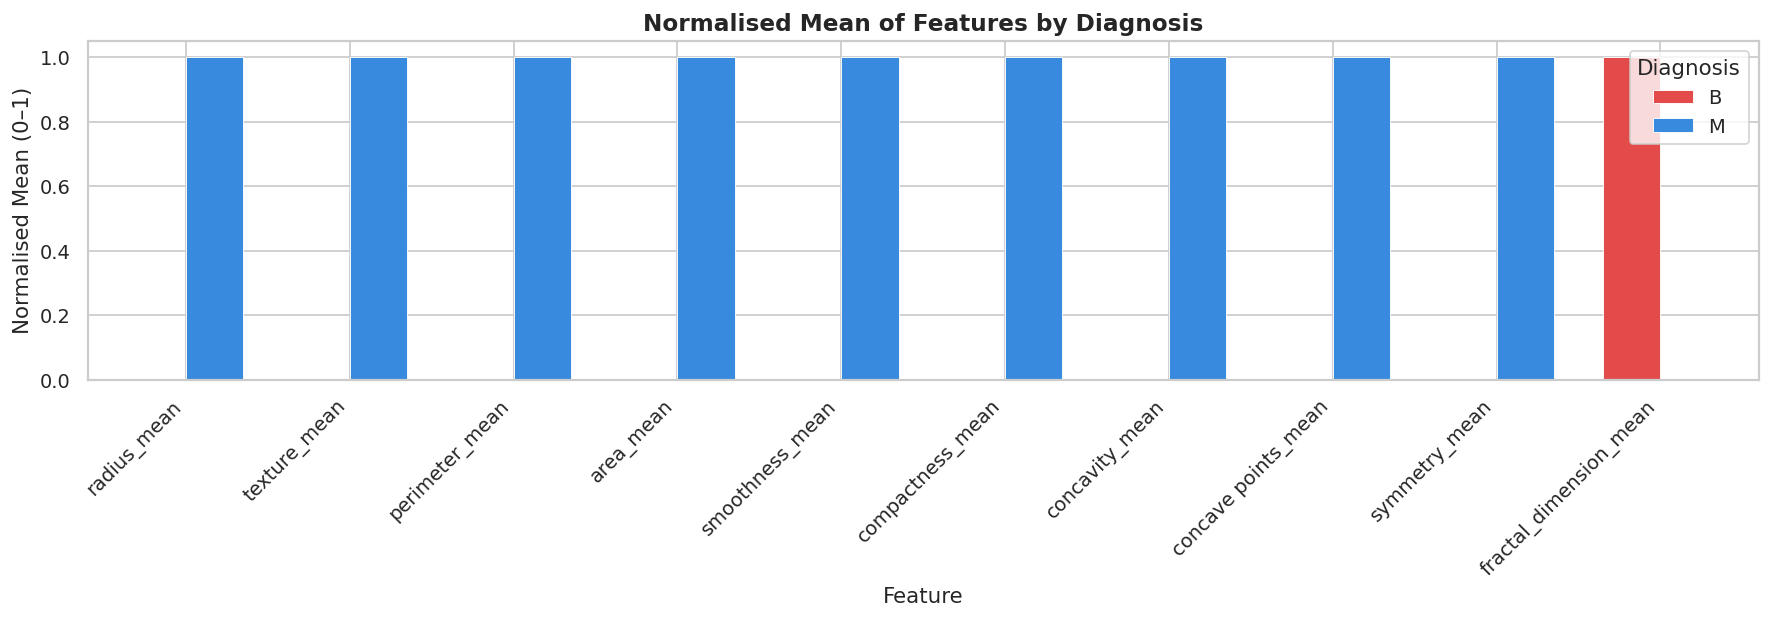

In [37]:
mean_by_diag = df.groupby("diagnosis")[mean_cols].mean()

mean_by_diag_norm = (mean_by_diag - mean_by_diag.min()) / \
                    (mean_by_diag.max() - mean_by_diag.min())   # normalise 0-1

mean_by_diag_norm.T.plot(kind="bar", figsize=(14, 5),
                          color=["#E24B4A", "#378ADD"], width=0.7,
                          edgecolor="white", linewidth=0.5)
plt.title("Normalised Mean of Features by Diagnosis", fontsize=13, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Normalised Mean (0–1)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

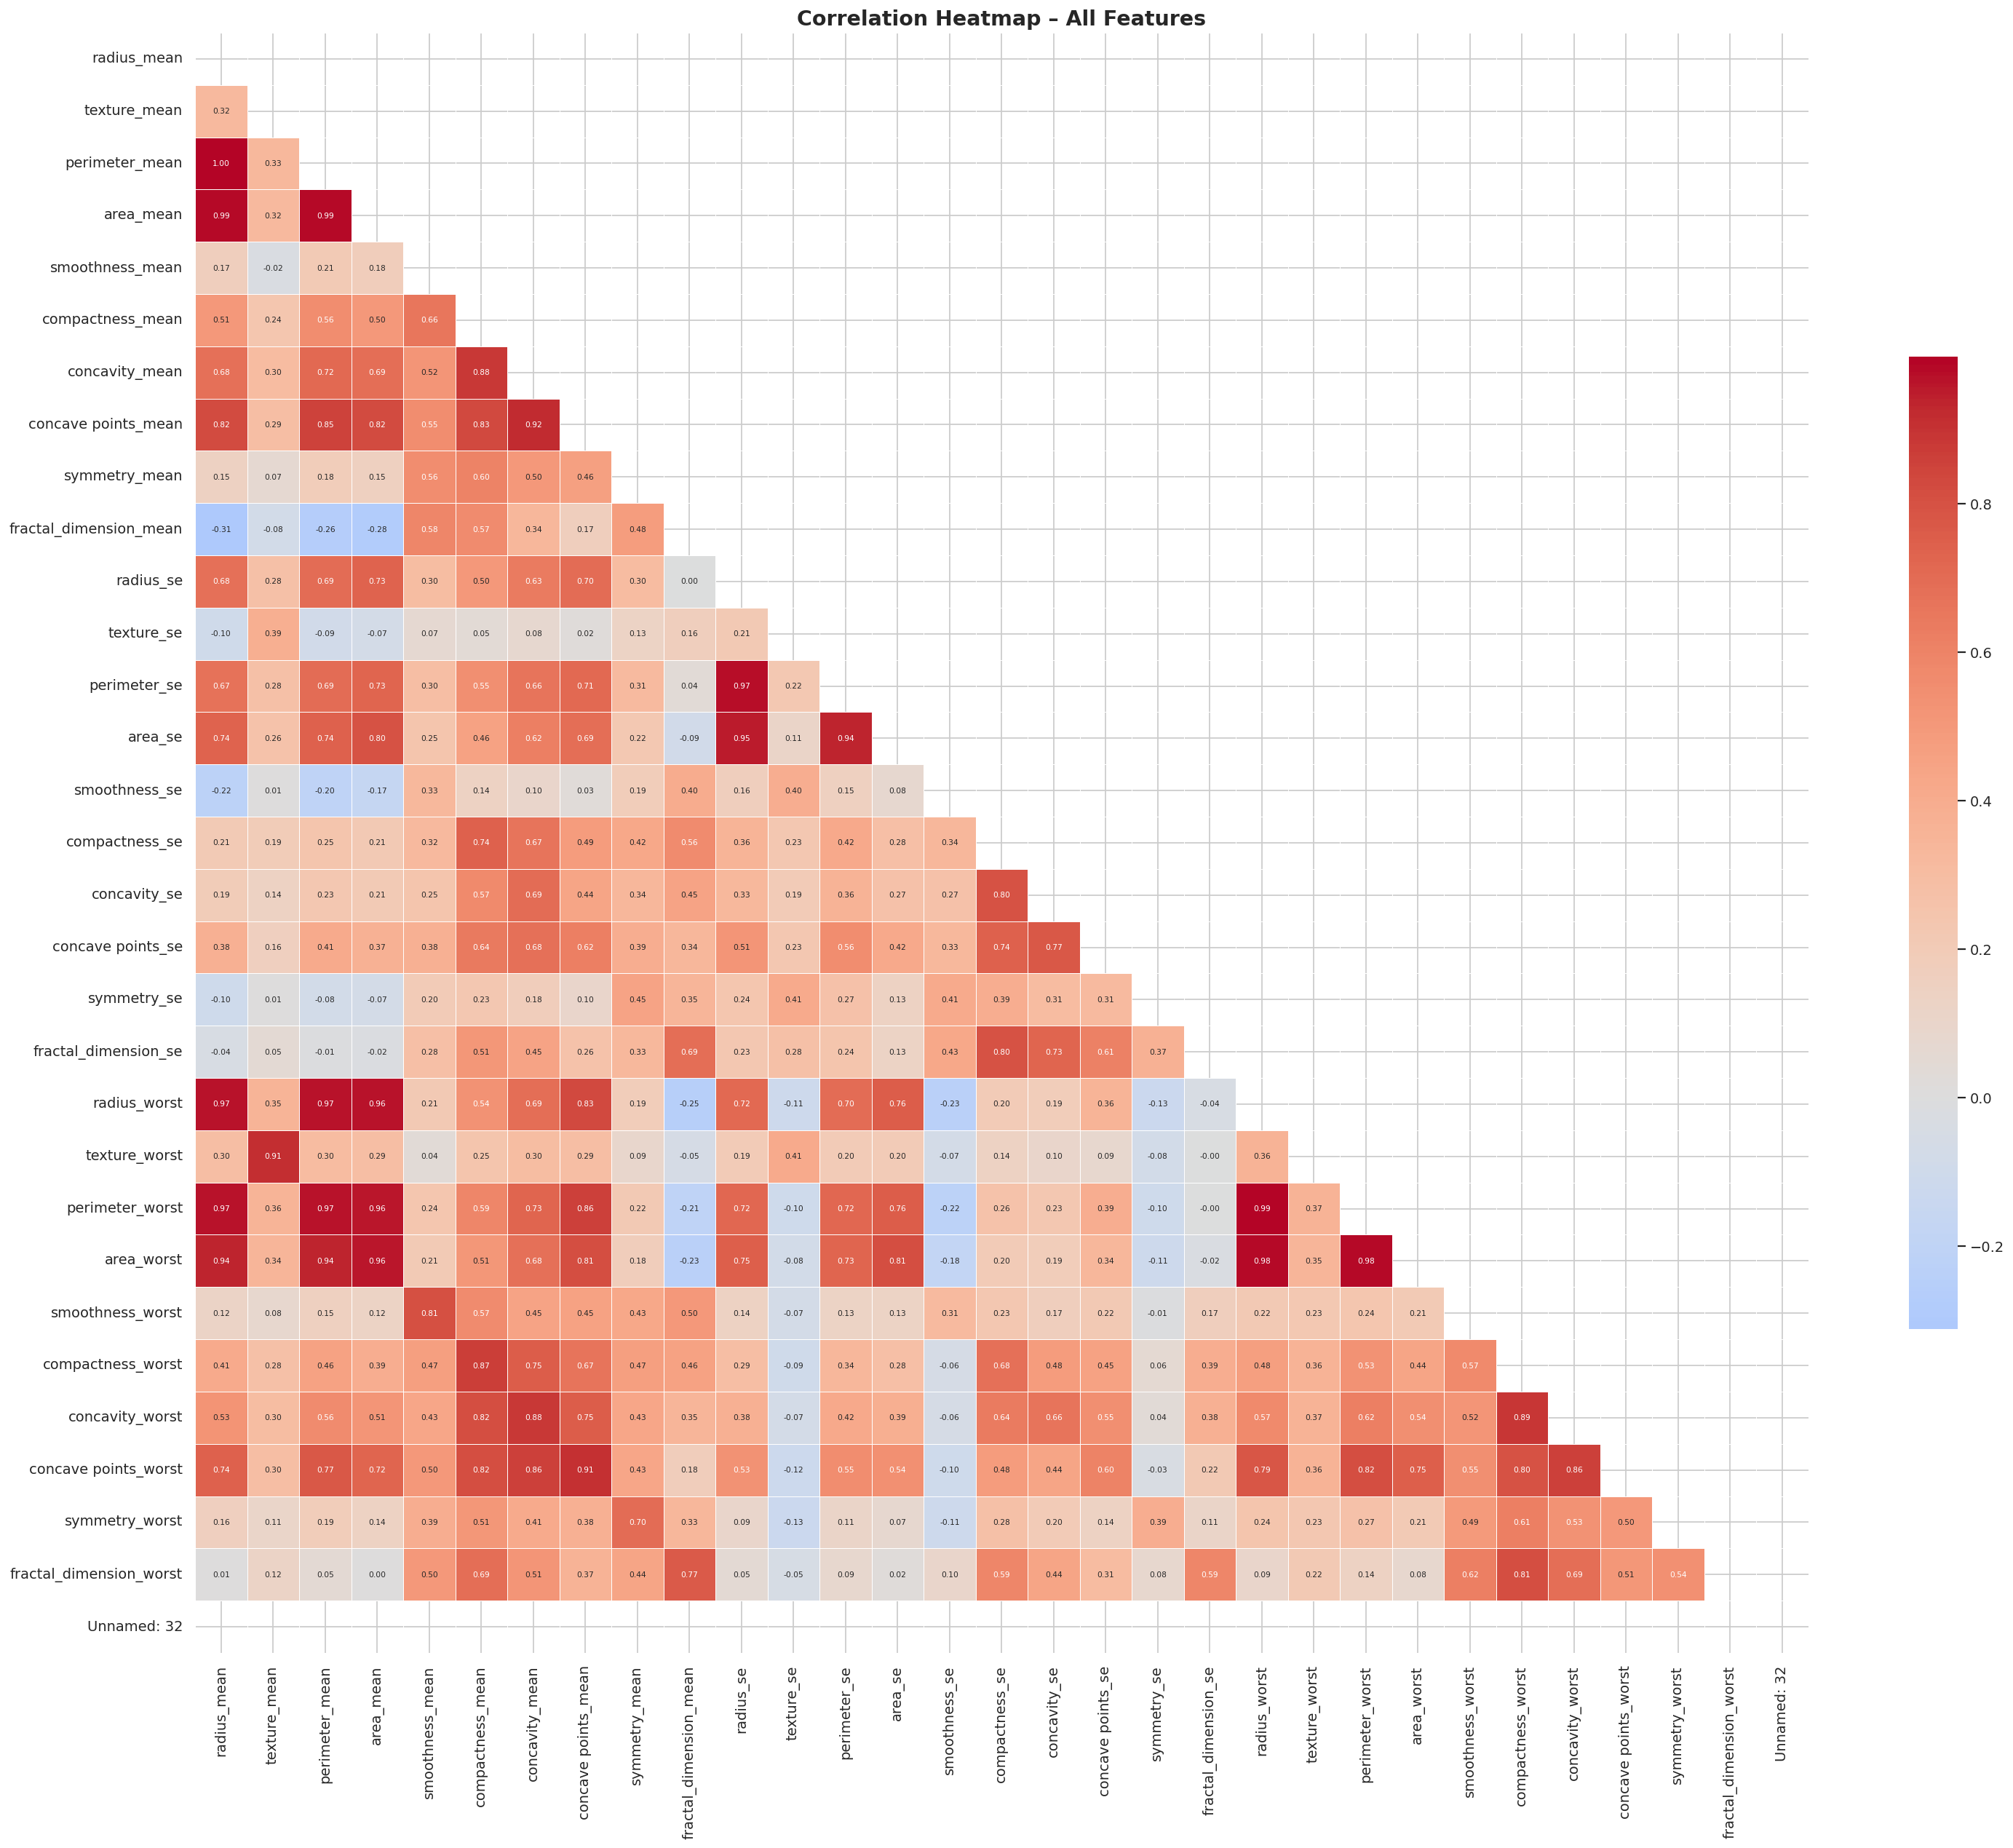

In [38]:
fig, ax = plt.subplots(figsize=(24, 20))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, linecolor="white",
            annot_kws={"size": 6}, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Correlation Heatmap – All Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


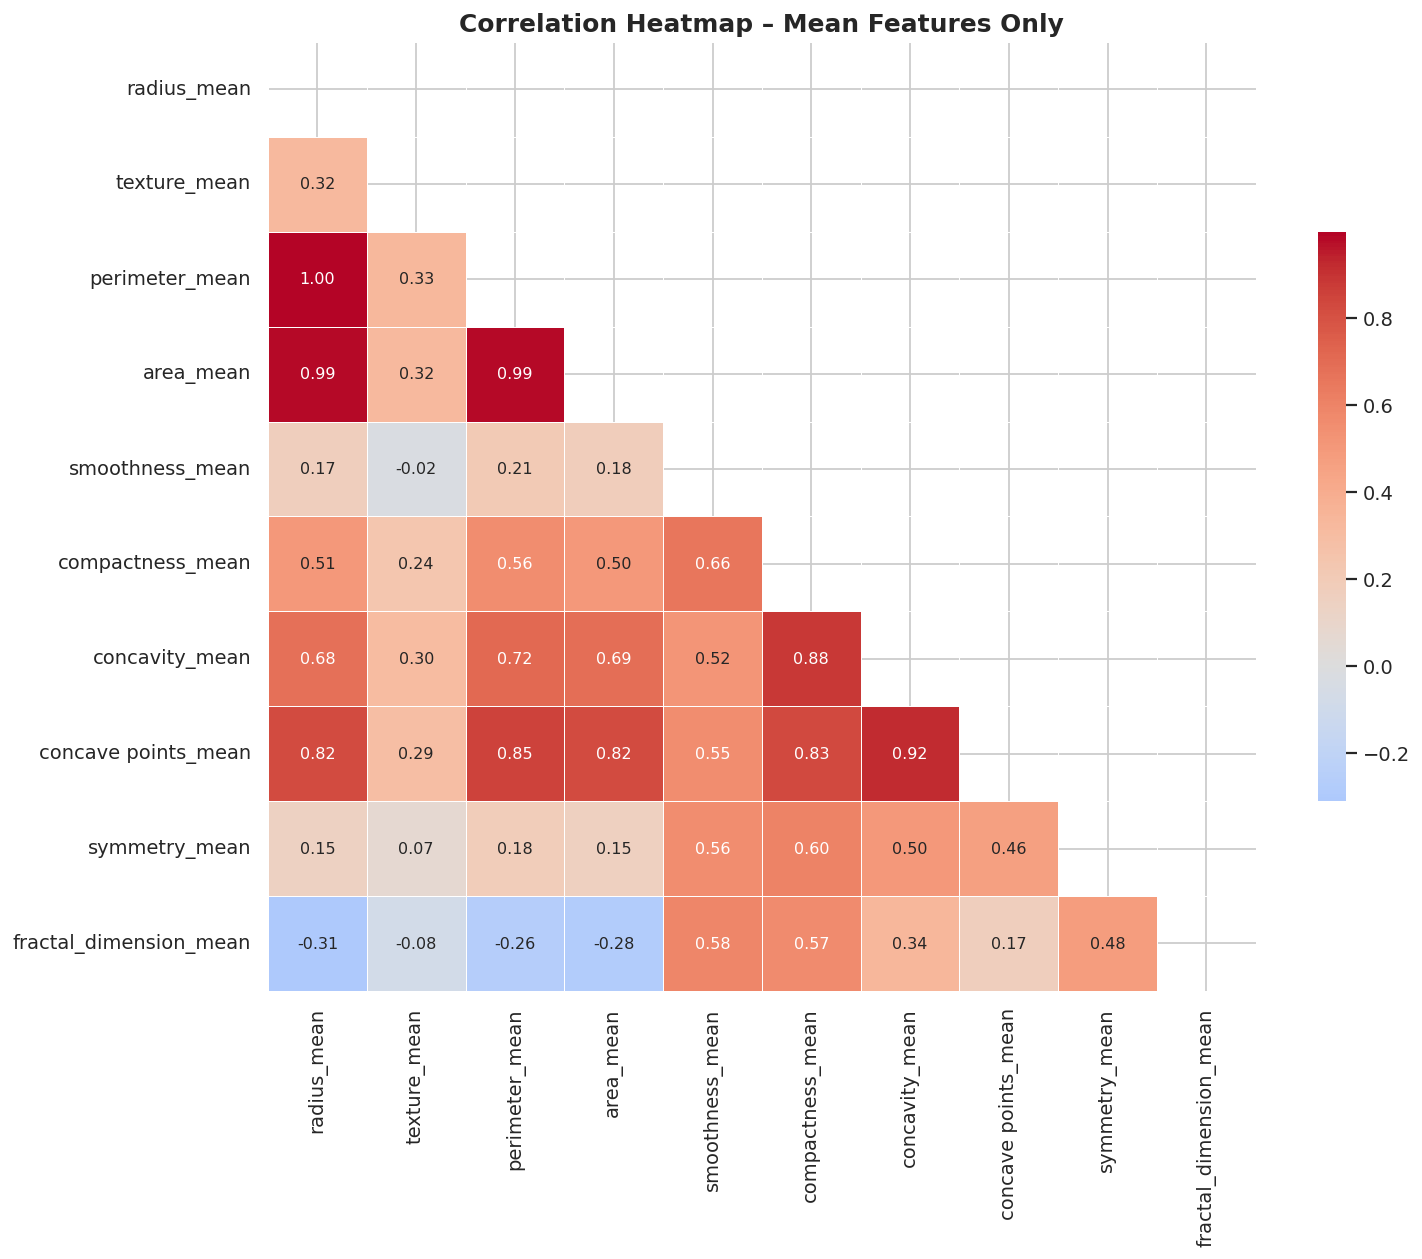

In [39]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_mean = df[mean_cols].corr()
mask_mean = np.triu(np.ones_like(corr_mean, dtype=bool))

sns.heatmap(corr_mean, mask=mask_mean, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="white",
            annot_kws={"size": 9}, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Correlation Heatmap – Mean Features Only", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
print("=" * 60)
print("TOP 10 HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)")
print("=" * 60)
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                  .stack()
                  .reset_index())
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs["abs_corr"] = corr_pairs["Correlation"].abs()
top_corr = corr_pairs[corr_pairs["abs_corr"] > 0.8].sort_values("abs_corr", ascending=False)
print(top_corr[["Feature_1", "Feature_2", "Correlation"]].to_string(index=False))

TOP 10 HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)
              Feature_1           Feature_2  Correlation
         perimeter_mean         radius_mean     0.997855
        perimeter_worst        radius_worst     0.993708
              area_mean         radius_mean     0.987357
              area_mean      perimeter_mean     0.986507
             area_worst        radius_worst     0.984015
             area_worst     perimeter_worst     0.977578
           perimeter_se           radius_se     0.972794
        perimeter_worst      perimeter_mean     0.970387
           radius_worst         radius_mean     0.969539
           radius_worst      perimeter_mean     0.969476
        perimeter_worst         radius_mean     0.965137
           radius_worst           area_mean     0.962746
             area_worst           area_mean     0.959213
        perimeter_worst           area_mean     0.959120
                area_se           radius_se     0.951830
             area_worst      perimete

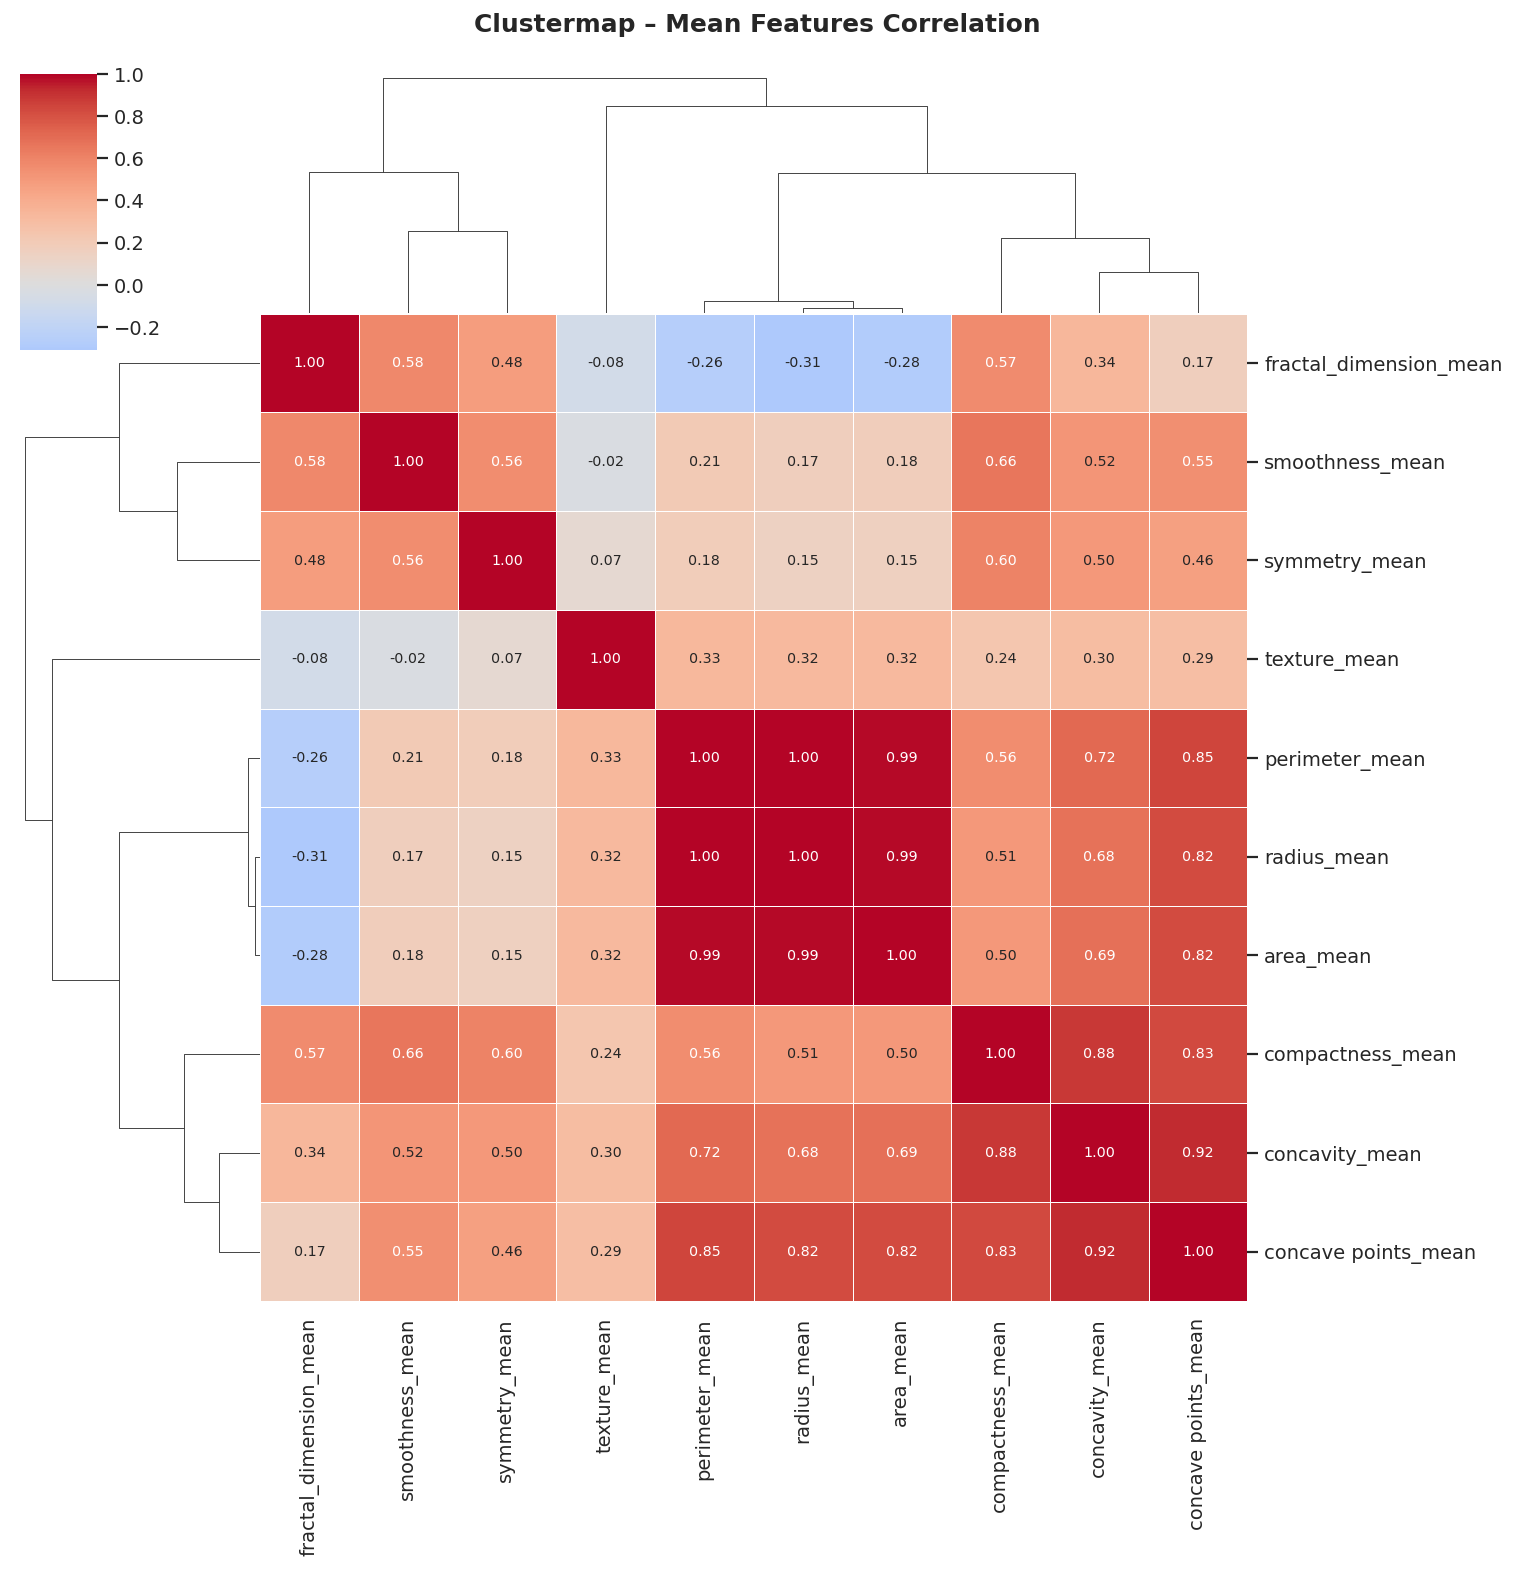

In [41]:
g = sns.clustermap(df[mean_cols].corr(), cmap="coolwarm", center=0,
                   annot=True, fmt=".2f", annot_kws={"size": 8},
                   figsize=(12, 12), linewidths=0.4)
g.fig.suptitle("Clustermap – Mean Features Correlation", y=1.02,
               fontsize=14, fontweight="bold")
plt.show()

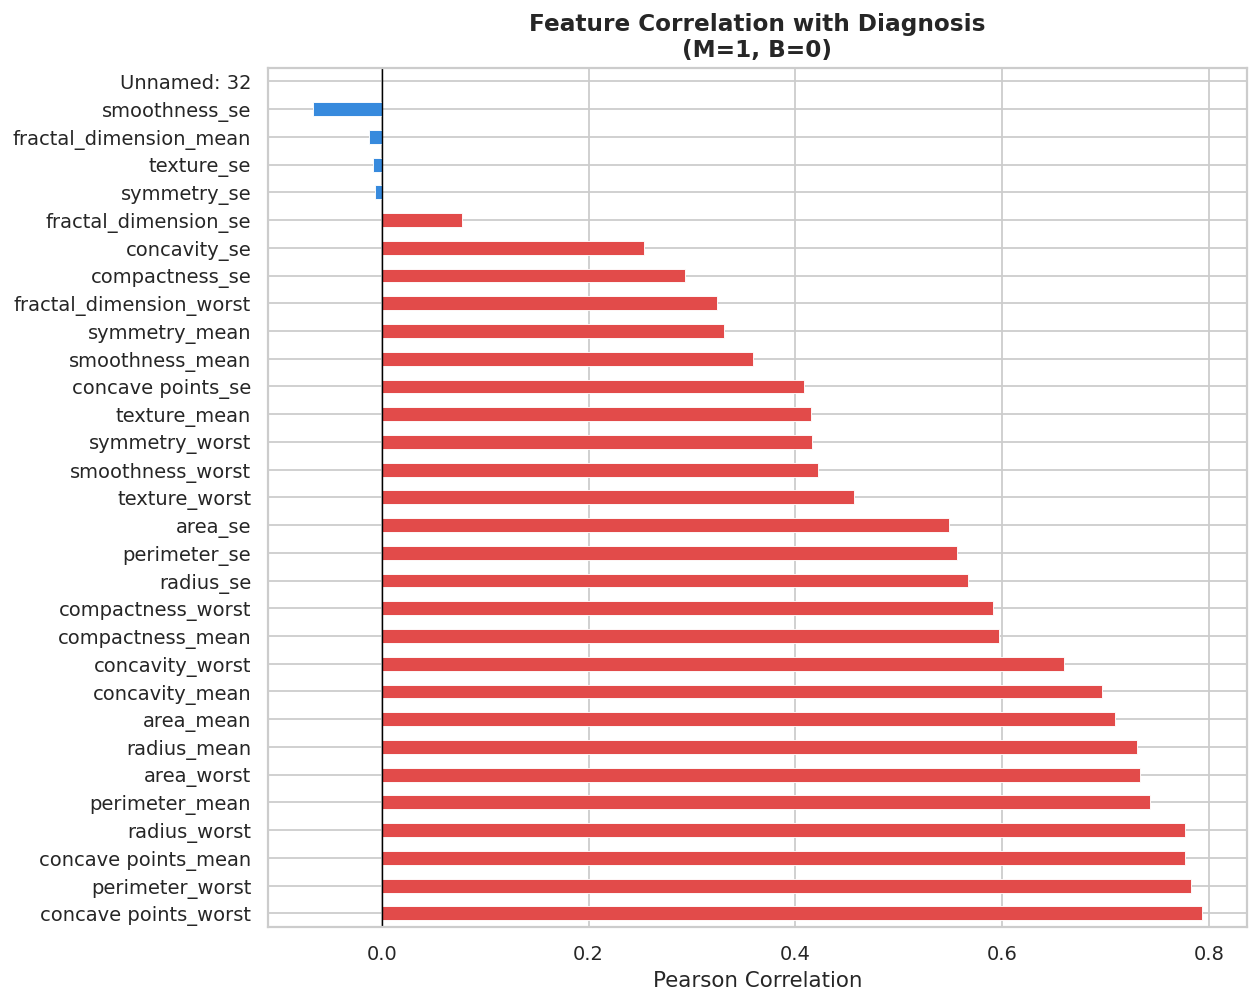


 EDA Complete!
Features most correlated with Malignancy:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636


In [42]:
df["diagnosis_num"] = (df["diagnosis"] == "M").astype(int)
diag_corr = df[numeric_cols.tolist() + ["diagnosis_num"]].corr()["diagnosis_num"] \
              .drop("diagnosis_num").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#E24B4A" if v > 0 else "#378ADD" for v in diag_corr]
diag_corr.plot(kind="barh", color=colors_bar, edgecolor="white",
               linewidth=0.5, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Diagnosis\n(M=1, B=0)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()
df.drop(columns=["diagnosis_num"], inplace=True)
print("\n EDA Complete!")
print("Features most correlated with Malignancy:")
print(diag_corr.head(5).to_string())

In [43]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
numeric_cols = df.select_dtypes(include=np.number).columns.drop("id")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
df_standard = pd.DataFrame(X_scaled, columns=numeric_cols)
print(df_standard.describe().T[["mean", "std"]])

                                 mean      std
radius_mean             -1.373633e-16  1.00088
texture_mean             6.868164e-17  1.00088
perimeter_mean          -1.248757e-16  1.00088
area_mean               -2.185325e-16  1.00088
smoothness_mean         -8.366672e-16  1.00088
compactness_mean         1.873136e-16  1.00088
concavity_mean           4.995028e-17  1.00088
concave points_mean     -4.995028e-17  1.00088
symmetry_mean            1.748260e-16  1.00088
fractal_dimension_mean   4.745277e-16  1.00088
radius_se                2.372638e-16  1.00088
texture_se              -1.123881e-16  1.00088
perimeter_se            -1.123881e-16  1.00088
area_se                 -1.311195e-16  1.00088
smoothness_se           -1.529727e-16  1.00088
compactness_se           1.748260e-16  1.00088
concavity_se             1.623384e-16  1.00088
concave points_se        0.000000e+00  1.00088
symmetry_se              8.741299e-17  1.00088
fractal_dimension_se    -6.243785e-18  1.00088
radius_worst 

In [44]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
df_minmax = pd.DataFrame(X_scaled, columns=numeric_cols)
print(df_minmax.describe().T[["min", "max"]])

                         min  max
radius_mean              0.0  1.0
texture_mean             0.0  1.0
perimeter_mean           0.0  1.0
area_mean                0.0  1.0
smoothness_mean          0.0  1.0
compactness_mean         0.0  1.0
concavity_mean           0.0  1.0
concave points_mean      0.0  1.0
symmetry_mean            0.0  1.0
fractal_dimension_mean   0.0  1.0
radius_se                0.0  1.0
texture_se               0.0  1.0
perimeter_se             0.0  1.0
area_se                  0.0  1.0
smoothness_se            0.0  1.0
compactness_se           0.0  1.0
concavity_se             0.0  1.0
concave points_se        0.0  1.0
symmetry_se              0.0  1.0
fractal_dimension_se     0.0  1.0
radius_worst             0.0  1.0
texture_worst            0.0  1.0
perimeter_worst          0.0  1.0
area_worst               0.0  1.0
smoothness_worst         0.0  1.0
compactness_worst        0.0  1.0
concavity_worst          0.0  1.0
concave points_worst     0.0  1.0
symmetry_worst

In [45]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
df_robust = pd.DataFrame(X_scaled, columns=numeric_cols)
print(df_robust.describe().T[["mean", "std"]])

                             mean       std
radius_mean              0.185611  0.863737
texture_mean             0.079867  0.763950
perimeter_mean           0.198031  0.839923
area_mean                0.286394  0.971065
smoothness_mean          0.025900  0.742954
compactness_mean         0.178848  0.806548
concavity_mean           0.269521  0.788212
concave points_mean      0.287188  0.722720
symmetry_mean            0.058043  0.811073
fractal_dimension_mean   0.149360  0.838523
radius_se                0.328487  1.125001
texture_se               0.170057  0.861816
perimeter_se             0.330702  1.154686
area_se                  0.578167  1.663899
smoothness_se            0.222029  1.008572
compactness_se           0.259584  0.924532
concavity_se             0.222690  1.119661
concave points_se        0.122474  0.872495
symmetry_se              0.217824  0.993554
fractal_dimension_se     0.263162  1.145485
radius_worst             0.224773  0.836201
texture_worst            0.03092

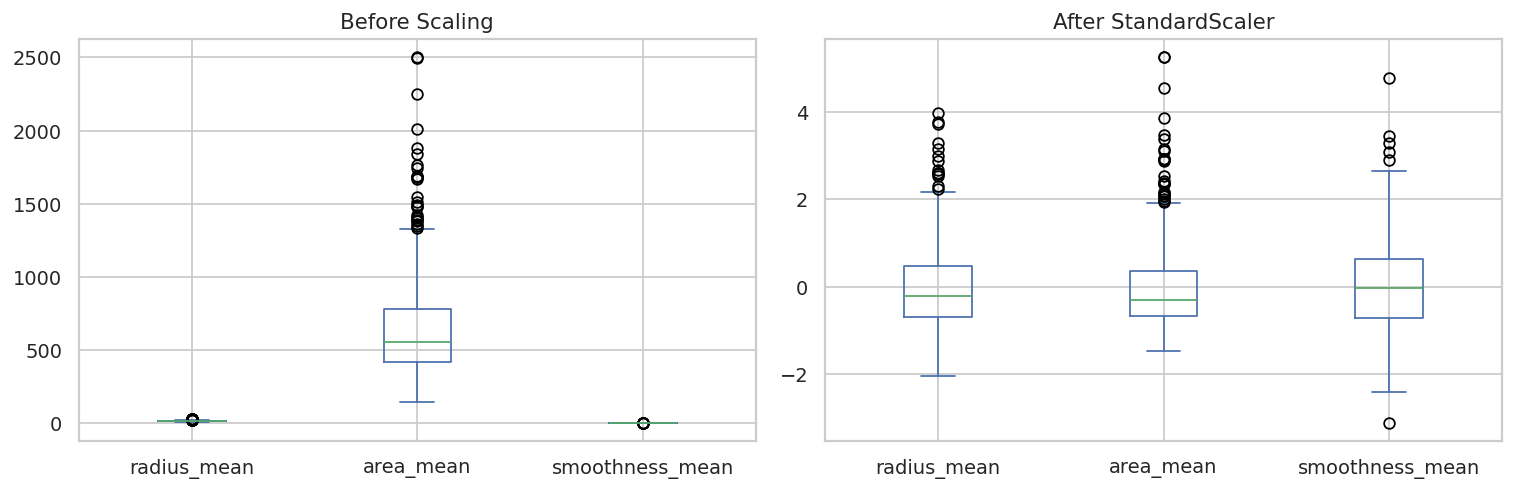

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling
df[["radius_mean", "area_mean", "smoothness_mean"]].plot(
    kind="box", ax=axes[0]
)
axes[0].set_title("Before Scaling")

# After scaling
df_standard[["radius_mean", "area_mean", "smoothness_mean"]].plot(
    kind="box", ax=axes[1]
)
axes[1].set_title("After StandardScaler")
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1 – Separate features and target
numeric_cols = df.select_dtypes(include=np.number).columns.drop("id")

X = df[numeric_cols]                                    # features
y = (df["diagnosis"] == "M").astype(int)               # target  M=1, B=0

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts()}")

X shape: (569, 31)
y shape: (569,)
Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keeps class ratio same in both splits
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (455, 31)
X_test shape  : (114, 31)
y_train shape : (455,)
y_test shape  : (114,)


In [50]:
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")


Train class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [51]:
print("SHAPE CHECK")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

SHAPE CHECK
X_train : (455, 31)
X_test  : (114, 31)
y_train : (455,)
y_test  : (114,)


In [52]:
print("CLASS DISTRIBUTION")

print(f"\ny_train value counts:\n{y_train.value_counts()}")
print(f"\ny_test value counts:\n{y_test.value_counts()}")

print(f"\ny_train percentage:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\ny_test percentage:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

CLASS DISTRIBUTION

y_train value counts:
diagnosis
0    285
1    170
Name: count, dtype: int64

y_test value counts:
diagnosis
0    72
1    42
Name: count, dtype: int64

y_train percentage:
diagnosis
0    62.64
1    37.36
Name: proportion, dtype: float64

y_test percentage:
diagnosis
0    63.16
1    36.84
Name: proportion, dtype: float64


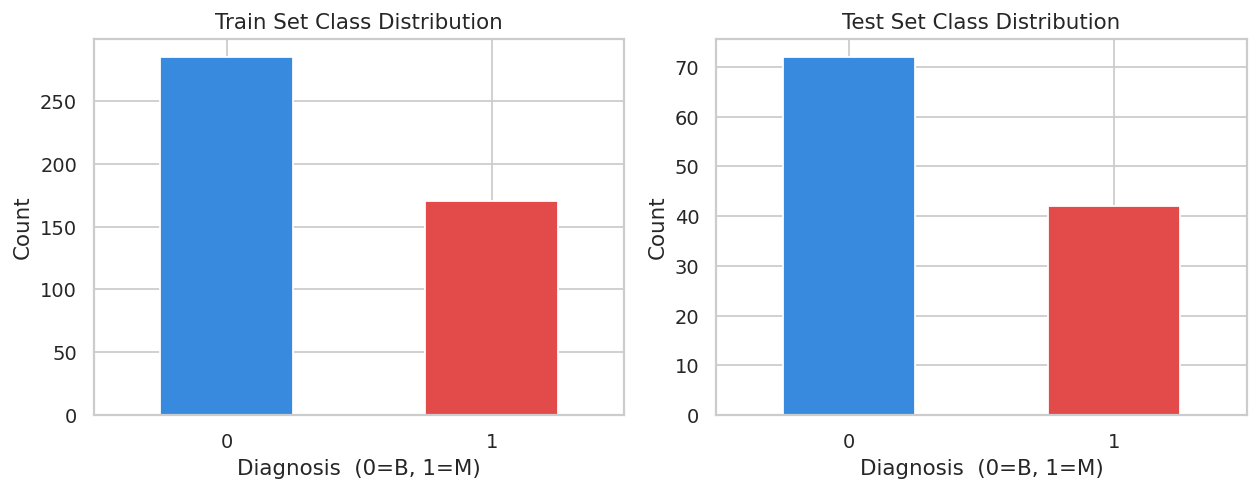

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind="bar", ax=axes[0],
                             color=["#378ADD", "#E24B4A"],
                             edgecolor="white")
axes[0].set_title("Train Set Class Distribution")
axes[0].set_xlabel("Diagnosis  (0=B, 1=M)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y_test.value_counts().plot(kind="bar", ax=axes[1],
                            color=["#378ADD", "#E24B4A"],
                            edgecolor="white")
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Diagnosis  (0=B, 1=M)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [56]:
print("MISSING VALUES IN TRAIN:", pd.DataFrame(X_train).isnull().sum().sum())
print("MISSING VALUES IN TEST :", pd.DataFrame(X_test).isnull().sum().sum())

MISSING VALUES IN TRAIN: 455
MISSING VALUES IN TEST : 114


In [59]:
print("Missing values in df:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nTotal NaN count: {df.isnull().sum().sum()}")

Missing values in df:
Unnamed: 32    569
dtype: int64

Total NaN count: 569


In [60]:
df = df.drop(columns=["Unnamed: 32"])
print(f"Shape after drop : {df.shape}")
print(f"NaN count        : {df.isnull().sum().sum()}")

Shape after drop : (569, 32)
NaN count        : 0


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Step 1 – Features and target
numeric_cols = df.select_dtypes(include=np.number).columns.drop("id")

X = df[numeric_cols]
y = (df["diagnosis"] == "M").astype(int)

# Step 2 – Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3 – Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"NaN in X_train : {np.isnan(X_train).sum()}")
print(f"NaN in X_test  : {np.isnan(X_test).sum()}")

NaN in X_train : 0
NaN in X_test  : 0


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("LOGISTIC REGRESSION")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy : 0.9649
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [63]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("DECISION TREE")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

DECISION TREE
Accuracy : 0.9298
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy : 0.9737
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [65]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

SVM
Accuracy : 0.9737
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [66]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy : 0.9561
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [68]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

print("MLP CLASSIFIER")
print(f"Accuracy : {accuracy_score(y_test, y_pred_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

MLP CLASSIFIER
Accuracy : 0.9649
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [69]:
mlp_model2 = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),  # 3 hidden layers
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

mlp_model2.fit(X_train, y_train)
y_pred_mlp2 = mlp_model2.predict(X_test)

print("MLP – 3 Hidden Layers")
print(f"Accuracy : {accuracy_score(y_test, y_pred_mlp2):.4f}")

MLP – 3 Hidden Layers
Accuracy : 0.9825


In [70]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Decision Tree",
                  "Random Forest", "SVM", "KNN", "MLP"],
    "Accuracy" : [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_dt),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_svm),
                  accuracy_score(y_test, y_pred_knn),
                  accuracy_score(y_test, y_pred_mlp)]
}).sort_values("Accuracy", ascending=False)

print(results.to_string(index=False))

              Model  Accuracy
                SVM  0.973684
      Random Forest  0.973684
                MLP  0.964912
Logistic Regression  0.964912
                KNN  0.956140
      Decision Tree  0.929825


In [71]:
mlp_tuned = MLPClassifier(
    hidden_layer_sizes=(200, 100, 50),  # deeper network
    activation="relu",
    solver="adam",
    alpha=0.0001,          # regularization
    learning_rate="adaptive",
    max_iter=500,
    random_state=42
)

mlp_tuned.fit(X_train, y_train)
y_pred_mlp_tuned = mlp_tuned.predict(X_test)

print(f"Tuned MLP Accuracy : {accuracy_score(y_test, y_pred_mlp_tuned):.4f}")

Tuned MLP Accuracy : 0.9912


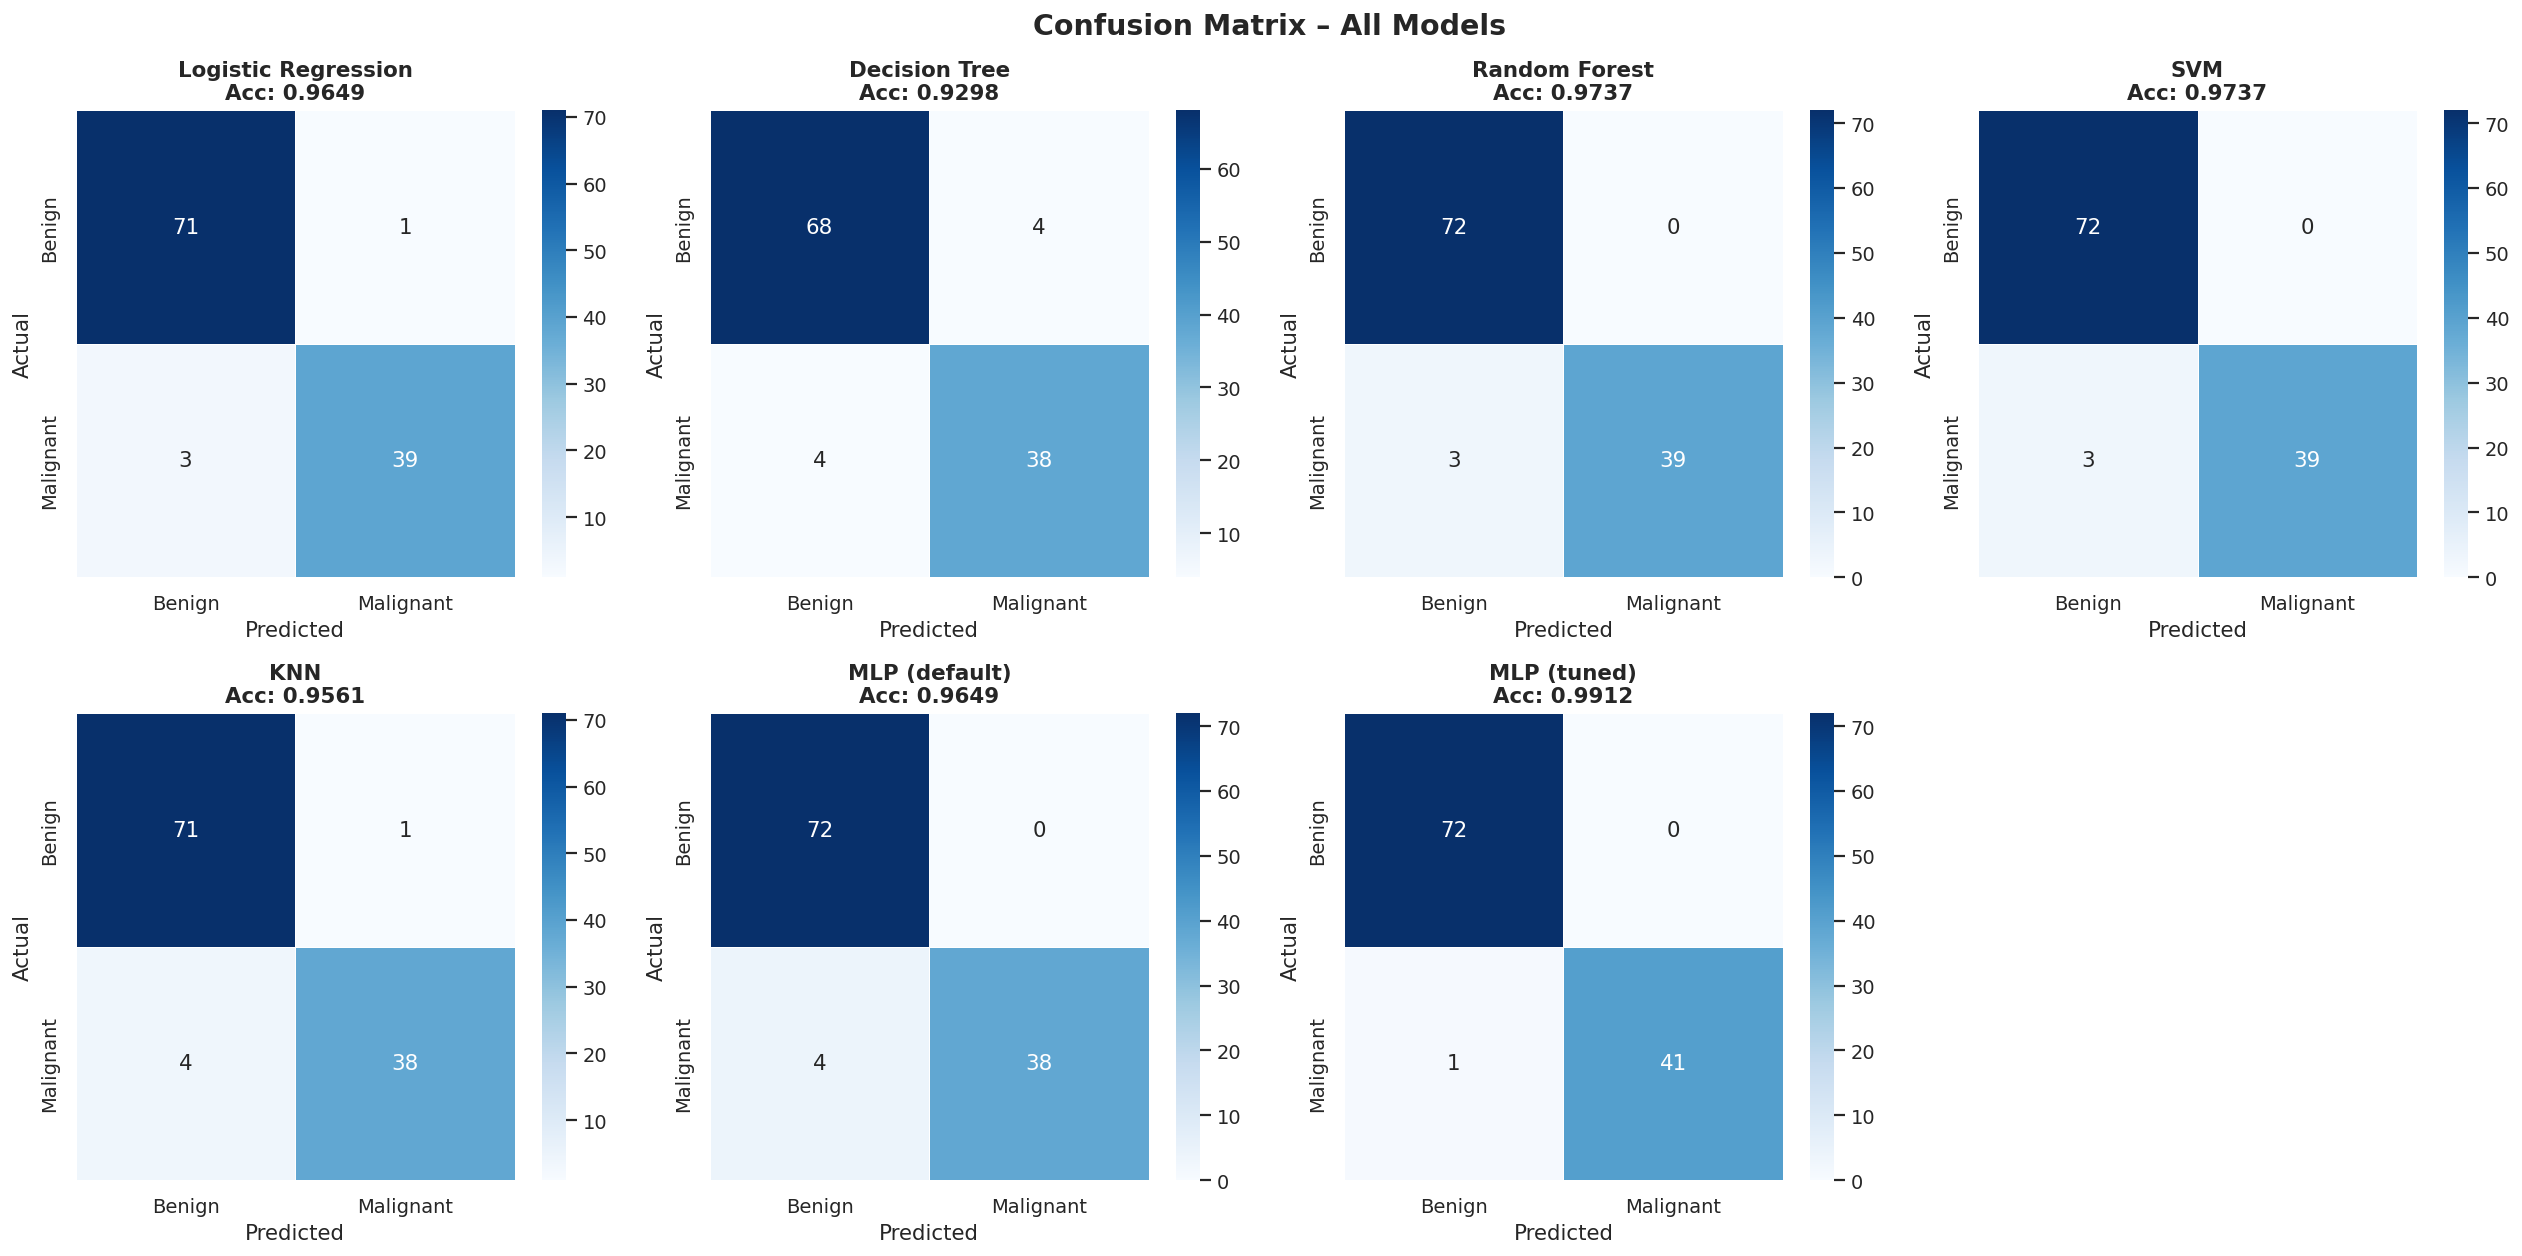

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression" : y_pred_lr,
    "Decision Tree"       : y_pred_dt,
    "Random Forest"       : y_pred_rf,
    "SVM"                 : y_pred_svm,
    "KNN"                 : y_pred_knn,
    "MLP (default)"       : y_pred_mlp,
    "MLP (tuned)"         : y_pred_mlp_tuned
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"],
                linewidths=0.5, ax=axes[i])
    axes[i].set_title(f"{name}\nAcc: {accuracy_score(y_test, y_pred):.4f}",
                      fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Confusion Matrix – All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [73]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    "C"      : [0.01, 0.1, 1, 10, 100],
    "solver" : ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42),
                       lr_params, cv=5, scoring="accuracy", n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("LOGISTIC REGRESSION – Best Params")
print(f"Best Params   : {lr_grid.best_params_}")
print(f"Best CV Score : {lr_grid.best_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, lr_grid.predict(X_test)):.4f}")

LOGISTIC REGRESSION – Best Params
Best Params   : {'C': 0.1, 'solver': 'liblinear'}
Best CV Score : 0.9758
Test Accuracy : 0.9825


In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    "n_estimators" : [50, 100, 200],
    "max_depth"    : [None, 5, 10, 20],
    "min_samples_split" : [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("RANDOM FOREST – Best Params")
print(f"Best Params   : {rf_grid.best_params_}")
print(f"Best CV Score : {rf_grid.best_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, rf_grid.predict(X_test)):.4f}")

RANDOM FOREST – Best Params
Best Params   : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score : 0.9670
Test Accuracy : 0.9737


In [76]:
from sklearn.svm import SVC

svm_params = {
    "C"      : [0.1, 1, 10, 100],
    "kernel" : ["rbf", "linear", "poly"],
    "gamma"  : ["scale", "auto"]
}

svm_grid = GridSearchCV(SVC(random_state=42),
                        svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train, y_train)

print("SVM – Best Params")
print(f"Best Params   : {svm_grid.best_params_}")
print(f"Best CV Score : {svm_grid.best_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, svm_grid.predict(X_test)):.4f}")

SVM – Best Params
Best Params   : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score : 0.9736
Test Accuracy : 0.9737


In [77]:
from sklearn.neural_network import MLPClassifier

mlp_params = {
    "hidden_layer_sizes" : [(100,), (200, 100), (200, 100, 50)],
    "activation"         : ["relu", "tanh"],
    "alpha"              : [0.0001, 0.001, 0.01],
    "learning_rate"      : ["constant", "adaptive"]
}

mlp_grid = GridSearchCV(MLPClassifier(max_iter=500, random_state=42),
                        mlp_params, cv=5, scoring="accuracy", n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print("MLP – Best Params")
print(f"Best Params   : {mlp_grid.best_params_}")
print(f"Best CV Score : {mlp_grid.best_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, mlp_grid.predict(X_test)):.4f}")

MLP – Best Params
Best Params   : {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (200, 100, 50), 'learning_rate': 'constant'}
Best CV Score : 0.9802
Test Accuracy : 0.9912


In [78]:
results_tuned = pd.DataFrame({
    "Model" : ["LR Tuned", "RF Tuned", "SVM Tuned", "MLP Tuned"],
    "Best Params"   : [lr_grid.best_params_, rf_grid.best_params_,
                       svm_grid.best_params_, mlp_grid.best_params_],
    "CV Score"      : [lr_grid.best_score_,  rf_grid.best_score_,
                       svm_grid.best_score_,  mlp_grid.best_score_],
    "Test Accuracy" : [accuracy_score(y_test, lr_grid.predict(X_test)),
                       accuracy_score(y_test, rf_grid.predict(X_test)),
                       accuracy_score(y_test, svm_grid.predict(X_test)),
                       accuracy_score(y_test, mlp_grid.predict(X_test))]
})

print(results_tuned.sort_values("Test Accuracy", ascending=False).to_string(index=False))

    Model                                                                                                Best Params  CV Score  Test Accuracy
MLP Tuned {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (200, 100, 50), 'learning_rate': 'constant'}  0.980220       0.991228
 LR Tuned                                                                          {'C': 0.1, 'solver': 'liblinear'}  0.975824       0.982456
 RF Tuned                                            {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}  0.967033       0.973684
SVM Tuned                                                                {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}  0.973626       0.973684


In [81]:
pip install tensorflow

In [82]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [83]:
import numpy as np

X_train_dl = np.array(X_train)
X_test_dl  = np.array(X_test)
y_train_dl = np.array(y_train)
y_test_dl  = np.array(y_test)

print(f"X_train shape : {X_train_dl.shape}")
print(f"X_test shape  : {X_test_dl.shape}")
print("Data ready ✓")

X_train shape : (455, 30)
X_test shape  : (114, 30)
Data ready ✓


In [84]:
model = keras.Sequential([
    layers.Input(shape=(X_train_dl.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,097 (203.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [85]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)
print("Model compiled ✓")

Model compiled ✓


In [86]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor             = "val_loss",
        patience            = 20,
        restore_best_weights= True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 10,
        min_lr   = 0.00001
    )
]
print("Callbacks ready ✓")

Callbacks ready ✓


In [87]:
history = model.fit(
    X_train_dl, y_train_dl,
    epochs           = 200,
    batch_size       = 32,
    validation_split = 0.2,
    callbacks        = callbacks,
    verbose          = 1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6374 - loss: 0.6618 - val_accuracy: 0.9231 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8709 - loss: 0.3270 - val_accuracy: 0.9341 - val_loss: 0.4638 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9231 - loss: 0.2365 - val_accuracy: 0.9231 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9615 - loss: 0.1753 - val_accuracy: 0.9560 - val_loss: 0.2756 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9643 - loss: 0.1303 - val_accuracy: 0.9670 - val_loss: 0.2192 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9643 - loss: 0.1209 - val_accuracy: 0.9670 - val_loss: 0.1853 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9780 - loss: 0.1063 - 

In [88]:
test_loss, test_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.9825
Test Loss     : 0.0772


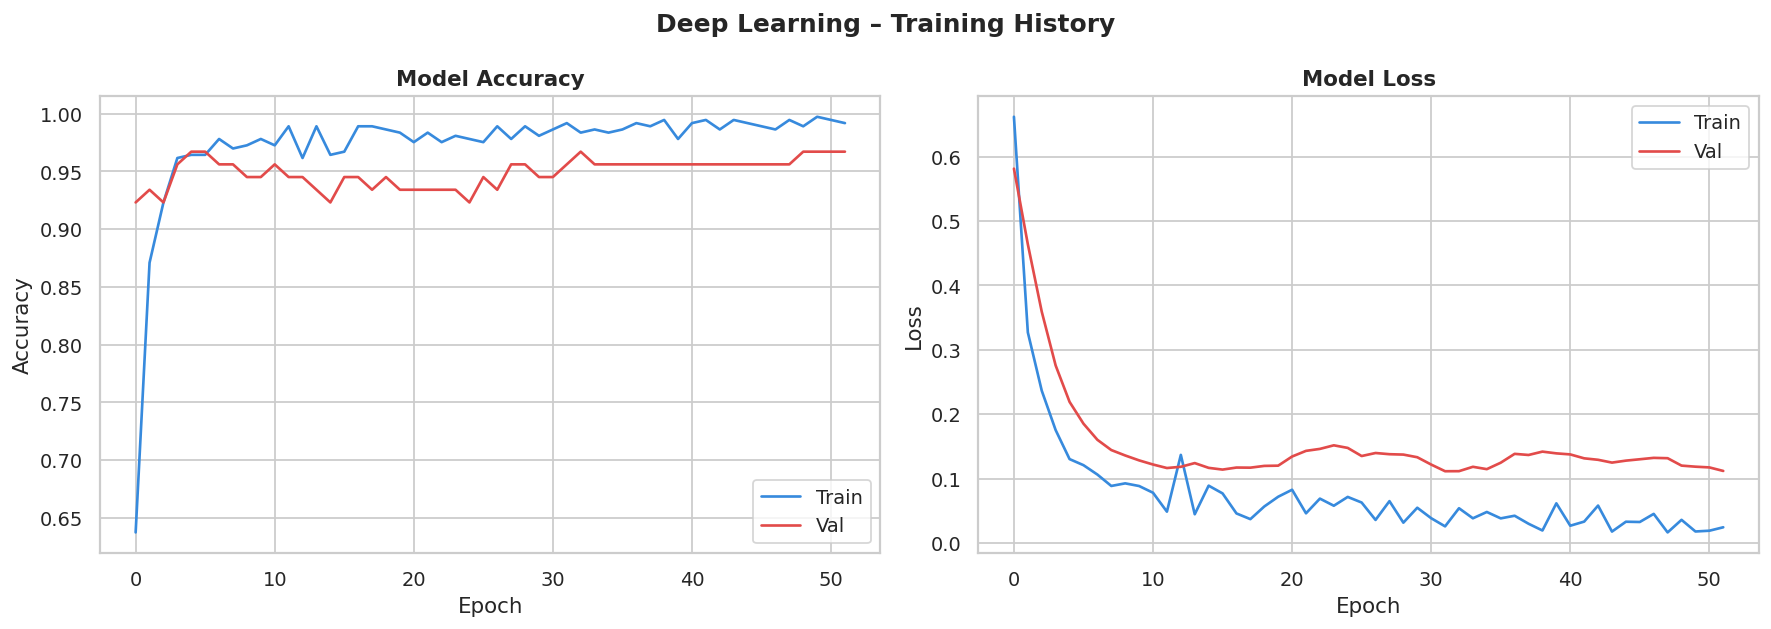

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train", color="#378ADD")
axes[0].plot(history.history["val_accuracy"], label="Val",   color="#E24B4A")
axes[0].set_title("Model Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train", color="#378ADD")
axes[1].plot(history.history["val_loss"], label="Val",   color="#E24B4A")
axes[1].set_title("Model Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Deep Learning – Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



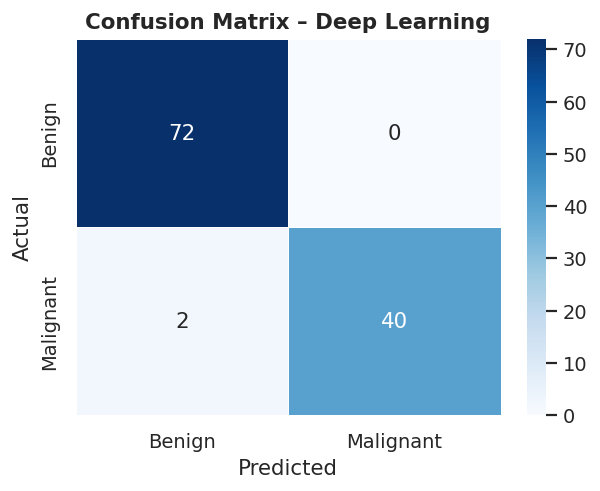

In [90]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_dl = (model.predict(X_test_dl) > 0.5).astype(int)

print(classification_report(y_test_dl, y_pred_dl,
      target_names=["Benign", "Malignant"]))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_dl, y_pred_dl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"],
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix – Deep Learning", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()